In [5]:
import numpy as np
import numpy.random as npr
import matplotlib.pyplot as plt
from scipy.spatial import KDTree
import matplotlib.colors as mcol
import matplotlib.cm as mcm
import scipy.stats as sts
from matplotlib.lines import Line2D
from matplotlib import ticker
from matplotlib.legend import Legend
import scipy.optimize as sopt
from sim_read import *

#from colossus.cosmology import cosmology
#from colossus.lss import peaks

plt.style.use('./presentation.mplstyle')

In [6]:
#cosmology.setCosmology('planck15')

gls = sim(exgrp_fields=['GroupFirstSub'],exsub_fields=['SubhaloMass','SubhaloStellarPhotometrics'])
sim.mass_add(gls)

In [19]:
h0 = 0.677
dconv = 1e-3/h0
mconv = 10 - np.log10(h0)

def samp_selc(floor=7.5,thresh=9.5,NN=5,hfloor=10):
    massive_gal,dwarf_gal = dwf_select(gls.sub.mst,thresh,floor)
    all_gal = np.array([*dwarf_gal,*massive_gal])
    
    rh0 = len(all_gal)/50.0**3
    print(len(all_gal),rh0)

    back_host = np.genfromtxt('backsplash.txt',usecols=0,dtype='int')
    back_dz0 = np.genfromtxt('backsplash.txt',usecols=3,dtype='float')
    back_gal = np.genfromtxt('backsplash.txt',usecols=2,dtype='int')

    dhost = [[],[],[]]
    llg,llt,llh,llr = [[],[],[]],[[],[],[]],[[],[],[]],[[],[],[]]
    x200,v200 = [[],[],[]],[[],[],[]]
    dhp,mdb = [[],[],[]],[[],[],[]]

    all_gal_pos =  gls.sub.SubhaloPos[all_gal,:]
    massive_gal_pos = gls.sub.SubhaloPos[massive_gal,:] 


    for j in back_gal:
        lh = gls.sub.SubhaloGrNr[j]
        blh = (np.where(j==back_gal)[0])[0]

        #nu = peaks.peakHeight(1e10*gls.hst.Group_M_Crit200[back_host[blh]], 0)
        #Rsp = dconv*gls.hst.Group_R_Crit200[back_host[blh]] * 0.81*(1+0.97*np.exp(-nu/2.44))
        
        if gls.hst.group_m200[lh]>=hfloor and gls.sub.mst[j]>floor:
                rall = wrap_dist_1n(massive_gal_pos,gls.sub.SubhaloPos[j,:])
                dist,ind = np.sort(rall)[:NN],np.argsort(rall)[:NN]
                    
                ind = massive_gal[ind]
                dist *= dconv
                MD_mass = mconv + np.log10(gls.sub.SubhaloMass[ind])
                          
                dhost[2].append(dist[0])
                llt[2].append(max(MD_mass - 3*np.log10(dist)) - 10.96)
                llh[2].append(lh)
                llg[2].append(j)
                x200[2].append(back_dz0[blh]/gls.hst.Group_R_Crit200[back_host[blh]])

                v = np.sum((gls.sub.SubhaloVel[j,:]-gls.hst.GroupVel[back_host[blh],:])*(gls.sub.SubhaloPos[j,:]-gls.hst.GroupPos[back_host[blh],:]))/back_dz0[blh]
                v200[2].append(4.8219e-3*v/np.sqrt(gls.hst.Group_M_Crit200[back_host[blh]]/gls.hst.Group_R_Crit200[back_host[blh]]))

                dhp[2].append(ind[0])
                mdb[2].append(ind[np.argmax(MD_mass - 3*np.log10(dist))])
                    
                #dist0, ind0 = all_gal_tree.query(gls.sub.SubhaloPos[j,:], k=NN+1)
                rall = wrap_dist_1n(all_gal_pos,gls.sub.SubhaloPos[j,:])
                dist0 = np.sort(rall)[:5]
                dist0 *= dconv
                llr[2].append(0.2387324146*(NN+1)/dist0[-1]**3)

        #all_gal = np.delete(all_gal,np.where(all_gal==j)[0])

    all_gal = np.array(list(set(all_gal)-set(back_gal)))
    
    dwarf_host,host_mem = np.unique(gls.sub.SubhaloGrNr[all_gal],return_inverse=True)
    Ndh = len(dwarf_host)
    for i in range(Ndh):  
        lh = dwarf_host[i]
        #print(gls.hst.group_m200[lh])

        #nu = peaks.peakHeight(1e10*gls.hst.Group_M_Crit200[lh], 0)
        #Rsp = dconv*gls.hst.Group_R_Crit200[lh] * 0.81*(1+0.97*np.exp(-nu/2.44))
        
        if gls.hst.group_m200[lh]>=hfloor:
            dw_mem = all_gal[np.where(host_mem==i)[0]]

            stellar_sort = np.argsort(gls.sub.mst[dw_mem])
            cen = dw_mem[stellar_sort[-1]]

            if len(dw_mem)>=1:
                if cen==gls.hst.GroupFirstSub[lh]:
                        rall = wrap_dist_1n(massive_gal_pos,gls.sub.SubhaloPos[cen,:])
                        dist,ind = np.sort(rall)[:5],np.argsort(rall)[:5]
                        ind = massive_gal[ind]  
                        dist *= dconv
                        MD_mass = mconv + np.log10(gls.sub.SubhaloMass[ind])
        
                        dhost[0].append(dist[0])
                        llt[0].append(max(MD_mass - 3*np.log10(dist)) - 10.96)
                        llh[0].append(lh)
                        llg[0].append(cen)
                        x200[0].append(0)
                        v200[0].append(0)
        
                        dhp[0].append(ind[0])
                        mdb[0].append(ind[np.argmax(MD_mass - 3*np.log10(dist))])
                        
                        rall = wrap_dist_1n(all_gal_pos,gls.sub.SubhaloPos[cen,:])
                        dist0 = np.sort(rall)[:5]
                        dist0 *= dconv
                        llr[0].append(0.2387324146*(NN+1)/dist0[-1]**3)

                if len(dw_mem)>1:
                    for j in dw_mem[stellar_sort[:-1]]:
                        rall = wrap_dist_1n(massive_gal_pos,gls.sub.SubhaloPos[j,:])
                        dist,ind = np.sort(rall)[:NN],np.argsort(rall)[:NN]

                        ind = massive_gal[ind]  
                        dist *= dconv
                        MD_mass = mconv + np.log10(gls.sub.SubhaloMass[ind])

                        x=wrap_dist_0n(gls.sub.SubhaloPos[j,:],gls.hst.GroupPos[lh,:])/gls.hst.Group_R_Crit200[lh]
                        v = np.sum((gls.sub.SubhaloVel[j,:]-gls.hst.GroupVel[lh,:])*(gls.sub.SubhaloPos[j,:]-gls.hst.GroupPos[lh,:]))/wrap_dist_0n(gls.sub.SubhaloPos[j,:],gls.hst.GroupPos[lh,:])

                        rall0 = wrap_dist_1n(all_gal_pos,gls.sub.SubhaloPos[j,:])
                        dist0 = np.sort(rall0)[:5]
                        dist0 *= dconv
                        
                        if gls.hst.group_m200[lh]<11.5 or (gls.hst.group_m200[lh]>=11.5 and x<1):
                            dhost[1].append(dist[0])
                            llt[1].append(max(MD_mass - 3*np.log10(dist)) - 10.96)
                            llh[1].append(lh)
                            llg[1].append(j)
                            x200[1].append(x)
                            v200[1].append(4.8219e-3*v/np.sqrt(gls.hst.Group_M_Crit200[lh]/gls.hst.Group_R_Crit200[lh]))
    
                            dhp[1].append(ind[0])
                            mdb[1].append(ind[np.argmax(MD_mass - 3*np.log10(dist))])
                            
                            llr[1].append(0.2387324146*(NN+1)/dist0[-1]**3)
                            
                        elif gls.hst.group_m200[lh]>=11.5 and x>1:
                            dhost[0].append(dist[0])
                            llt[0].append(max(MD_mass - 3*np.log10(dist)) - 10.96)
                            llh[0].append(lh)
                            llg[0].append(j)
                            x200[0].append(x)
                            v200[0].append(4.8219e-3*v/np.sqrt(gls.hst.Group_M_Crit200[lh]/gls.hst.Group_R_Crit200[lh]))
    
                            dhp[0].append(ind[0])
                            mdb[0].append(ind[np.argmax(MD_mass - 3*np.log10(dist))])
                            
                            llr[0].append(0.2387324146*(NN+1)/dist0[-1]**3)
                    
        
    return llt,llh,llg,llr,dhost,x200,v200,dhp,mdb

In [20]:
massive_gal,dwarf_gal = dwf_select(gls.sub.mst)
sfms_intercept,sfms_slope = dwf_sfms(gls.sub.mst,gls.sub.ssfr)

llt,llh,llg,llr,dhost,x200,v200,dhp,mdb =  samp_selc(hfloor=9)

N_lll = [len(llh[k]) for k in range(3)]
print(N_lll)
bin_mk = ['o','D','s']

1494 10829
1494 10829
-8.346120696830761 -0.17679571397785238
1494 10829
12323 0.098584


/var/folders/h6/wvvht_j93kdd56hj5zln7l_h0vlgf3/T/ipykernel_34234/3313343505.py:86: RuntimeWarning: divide by zero encountered in log10
  llt[0].append(max(MD_mass - 3*np.log10(dist)) - 10.96)
/var/folders/h6/wvvht_j93kdd56hj5zln7l_h0vlgf3/T/ipykernel_34234/3313343505.py:93: RuntimeWarning: divide by zero encountered in log10
  mdb[0].append(ind[np.argmax(MD_mass - 3*np.log10(dist))])
/var/folders/h6/wvvht_j93kdd56hj5zln7l_h0vlgf3/T/ipykernel_34234/3313343505.py:131: RuntimeWarning: divide by zero encountered in log10
  llt[0].append(max(MD_mass - 3*np.log10(dist)) - 10.96)
/var/folders/h6/wvvht_j93kdd56hj5zln7l_h0vlgf3/T/ipykernel_34234/3313343505.py:138: RuntimeWarning: divide by zero encountered in log10
  mdb[0].append(ind[np.argmax(MD_mass - 3*np.log10(dist))])
/var/folders/h6/wvvht_j93kdd56hj5zln7l_h0vlgf3/T/ipykernel_34234/3313343505.py:118: RuntimeWarning: divide by zero encountered in log10
  llt[1].append(max(MD_mass - 3*np.log10(dist)) - 10.96)
/var/folders/h6/wvvht_j93kdd56h

[6771, 4263, 1257]


In [21]:
llg_a = np.array([m for i in range(3) for m in llg[i]])
mst_a = np.array([m for i in range(3) for m in gls.sub.mst[llg[i]]])
llt_a = np.array([t for i in range(3) for t in llt[i]])
x200_a = np.array([x for i in range(3) for x in x200[i]])
v200_a = np.array([v for i in range(3) for v in v200[i]])
llh_a = np.array([h for i in range(3) for h in llh[i]])
m200_a = gls.hst.group_m200[llh_a]
dhost_a = np.array([d for i in range(3) for d in dhost[i]])
llr_a = np.log10(np.array([r for i in range(3) for r in llr[i]])) - np.log10(0.142904)
ssfr_a = np.array([s for i in range(3) for s in gls.sub.ssfr[llg[i]]])

dhp_a = np.array([t for i in range(3) for t in dhp[i]])
mdb_a = np.array([h for i in range(3) for h in mdb[i]])

dhp_c = np.array([t for i in range(2) for t in dhp[i]])
mdb_c = np.array([h for i in range(2) for h in mdb[i]])

#qnc_a = 1-np.heaviside(ssfr_a-(sfms_intercept -1 + sfms_slope*np.array(mst_a)),1)

host_bins = [np.where(((m200_a<11.5)|((m200_a>=11.5)&(x200_a>=1)))&(mst_a<9.5))[0],np.where((m200_a>=11.5)&(x200_a<1)&(mst_a<9.5))[0]]
dw_samp = np.where(((m200_a<11.5)|((m200_a>=11.5)&(x200_a>=1)))&(mst_a<9.5))[0]
print(len(dw_samp),len(host_bins[0]),len(host_bins[1]))


7510 7510 3300


In [31]:
#host_bins = [np.where(m200_a<11.5)[0],np.where(m200_a>=11.5)[0]]



llg_b = np.array([m for m in llg_a[host_bins[0]]])
mst_b = np.array([m for m in gls.sub.mst[llg_a[host_bins[0]]]])
llt_b = np.array([t for t in llt_a[host_bins[0]]])
x200_b = np.array([t for t in x200_a[host_bins[0]]])
llh_b = np.array([h for h in llh_a[host_bins[0]]])
m200_b = gls.hst.group_m200[llh_b]
dhost_b = np.array([d for d in dhost_a[host_bins[0]]])

dhp_b = np.array([t for t in dhp_a[host_bins[0]]])
mdb_b = np.array([h for h in mdb_a[host_bins[0]]])
ssfr_b = np.array([s for s in gls.sub.ssfr[llg_a[host_bins[0]]]])

llg_c = np.array([m for i in range(2) for m in llg[i]])
mst_c = np.array([m for i in range(2) for m in gls.sub.mst[llg[i]]])
llt_c = np.array([t for i in range(2) for t in llt[i]])
dhost_c = np.array([d for i in range(2) for d in dhost[i]])

x200_c = np.array([t for i in range(2) for t in x200[i]])
llh_c = np.array([h for i in range(2) for h in llh[i]])
m200_c = gls.hst.group_m200[llh_c]

host_bins_c = [np.where((m200_c<11.5)|((m200_c>=11.5)&(x200_c>=1)))[0],np.where((m200_c>=11.5)&(x200_c<1))[0]]

llg_d = np.array([m for m in llg_c[host_bins_c[0]]])
mst_d = np.array([m for m in gls.sub.mst[llg_c[host_bins_c[0]]]])
llt_d = np.array([t for t in llt_c[host_bins_c[0]]])
llh_d = np.array([h for h in llh_c[host_bins_c[0]]])
dhost_d = np.array([d for d in dhost_a[host_bins_c[0]]])
ssfr_d = np.array([s for s in gls.sub.ssfr[llg_c[host_bins_c[0]]]])

m200_d = m200_c[host_bins_c[0]]
dhp_d = np.array([t for t in dhp_c[host_bins_c[0]]])
mdb_d = np.array([t for t in mdb_c[host_bins_c[0]]])

#dw_samp = np.where((m200_a<11.5)&(mst_a<9.5))[0]
#print(len(np.unique(llh_a[dw_samp])))


7548 7548 3300


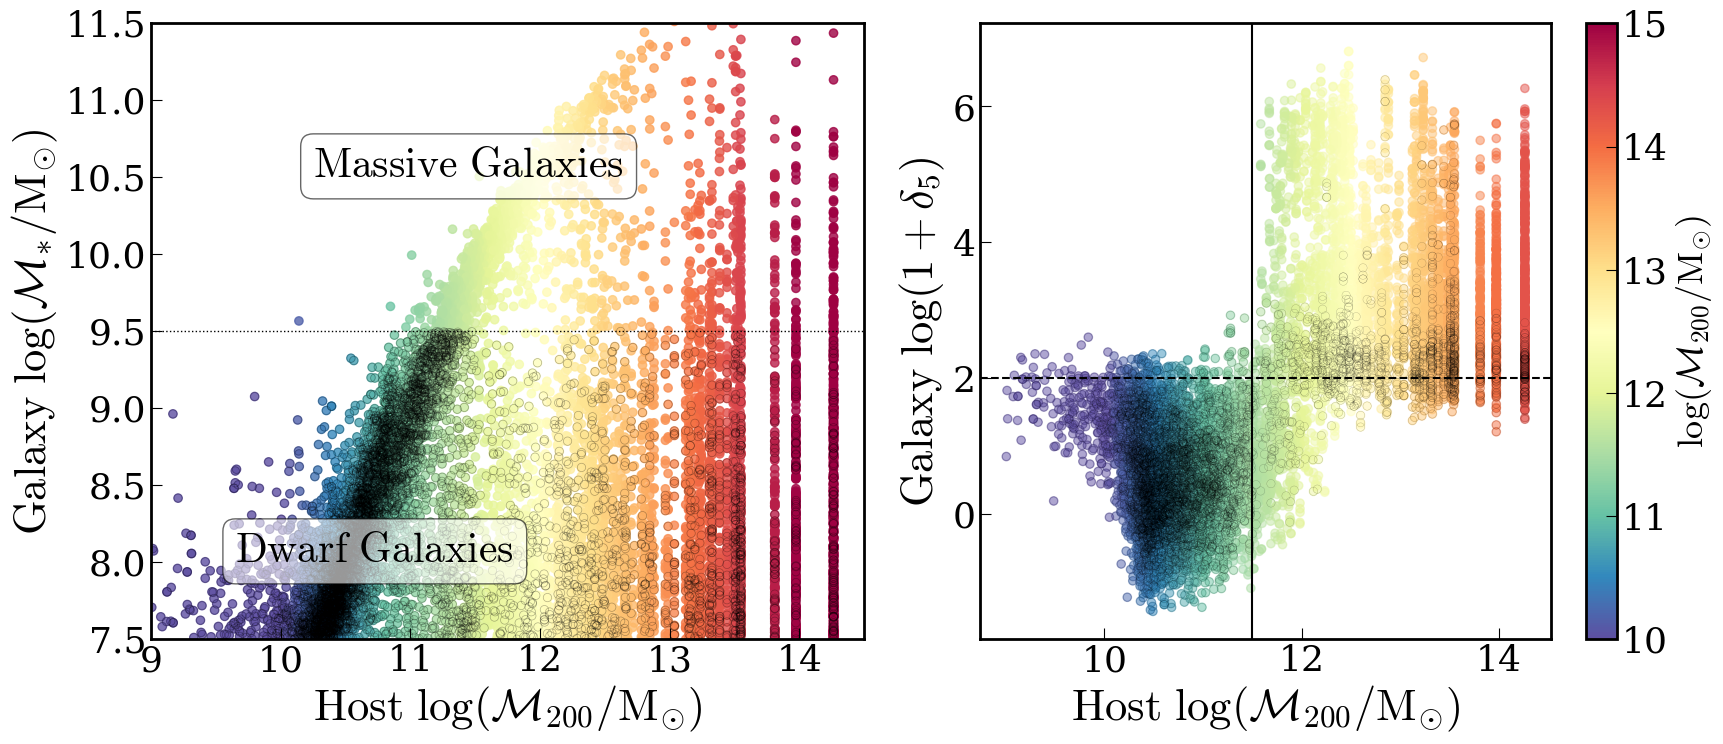

In [29]:
fig,ax=plt.subplots(1,4,figsize=(20,8),width_ratios=[0.46,0.075,0.46,0.005])

ax[0].scatter(m200_a,mst_a,c=m200_a,cmap=mcm.Spectral_r,vmin=10,vmax=14,alpha=0.8)
ax[0].scatter(m200_a[dw_samp],mst_a[dw_samp],c='none',edgecolors='black',marker='o',linewidth=0.5,alpha=0.3)

ax[0].set_xlim((9,14.5))
ax[0].set_ylim((7.5,11.5))
ax[0].axhline(9.5,ls=':',lw=1,color='black')
#ax[0].axvline(11.5,ymax=0.5,ls=':',lw=1,color='black')

ax[0].text(10.25,10.5,r'$Massive\ Galaxies$',fontsize=30,bbox=dict(facecolor='white',alpha=0.6, boxstyle='round'))
#ax[0].text(11.75,8,r'$Satellite\ Dwarfs$',fontsize=30,bbox=dict(facecolor='white',alpha=0.6, boxstyle='round'))
ax[0].text(9.65,8,r'$Dwarf\ Galaxies$',fontsize=30,bbox=dict(facecolor='white',alpha=0.6, boxstyle='round'))

ax[0].set_xlabel(r'$Host\ log(\mathcal{M}_{200}/M_{\odot})$',fontsize=32)
ax[0].set_ylabel(r'$Galaxy\ log(\mathcal{M}_{\ast}/M_{\odot})$',fontsize=32)

ax[2].scatter(m200_a,llr_a,c=m200_a,cmap=mcm.Spectral_r,vmin=10,vmax=15,alpha=0.5)
ax[2].scatter(m200_a[dw_samp],llr_a[dw_samp],c='none',edgecolors='black',marker='o',linewidth=0.25,alpha=0.3)

ax[2].axvline(11.5,color='black')
ax[2].axhline(2,color='black',ls='--')

ax[2].set_ylabel(r'$Galaxy\ log(1+\delta_5)$',fontsize=32)
ax[2].set_xlabel(r'$Host\ log(\mathcal{M}_{200}/M_{\odot})$',fontsize=32)

ax[1].set_axis_off()
ax[3].set_axis_off()

fig.colorbar(mcm.ScalarMappable(norm=mcol.Normalize(vmin=10, vmax=15),cmap=mcm.Spectral_r), ax=ax[2], orientation='vertical',label=r'$log(\mathcal{M}_{200}/M_{\odot})$')

ax[0].set_rasterized(True)
ax[2].set_rasterized(True)
plt.subplots_adjust(wspace=0.0)
plt.savefig('Bdens_map.pdf',bbox_inches='tight')


7510
3300


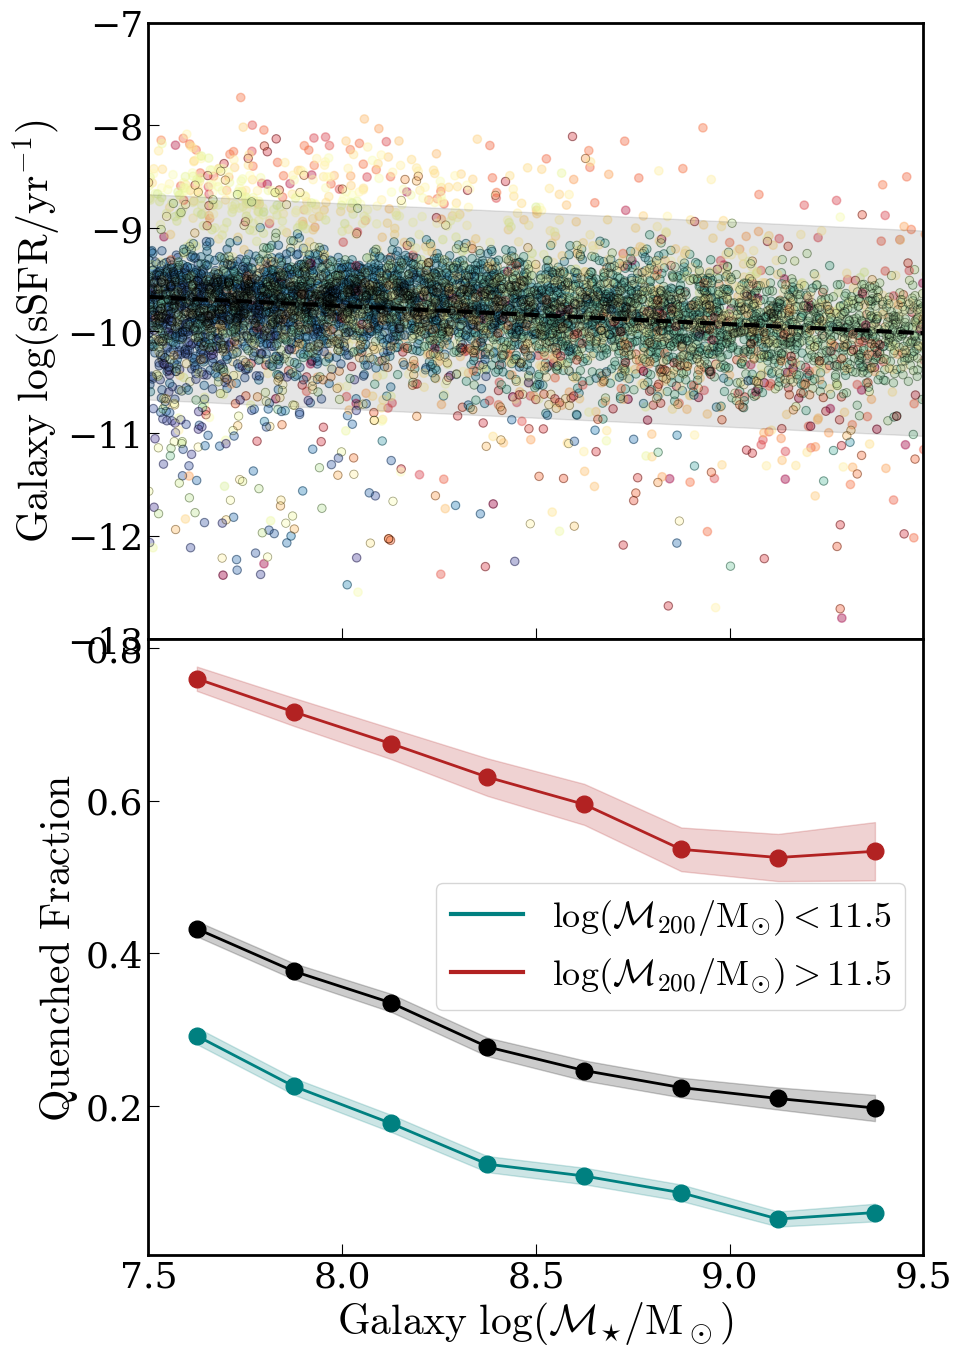

In [30]:
fig,ax=plt.subplots(2,1,figsize=(10,16),sharex=True)

mst_bins = np.linspace(7.5,9.5,9)
mst_bw = 0.5*(mst_bins[1]-mst_bins[0])
bin_cols = ['teal','firebrick']

Nbtsp = 1000

ax[0].scatter(mst_a,ssfr_a,c=m200_a,cmap=mcm.Spectral_r,vmin=10,vmax=14,alpha=0.4)
ax[0].scatter(mst_a[dw_samp],ssfr_a[dw_samp],c='none',edgecolors='black',marker='o',linewidth=0.5,alpha=0.4)

sfr_seq = sfms_intercept + sfms_slope*mst_bins
ax[0].plot(mst_bins,sfr_seq,color='black',ls='--',lw=3)
ax[0].fill_between(mst_bins,sfr_seq-1,sfr_seq+1,color='black',alpha=0.1)

boot_qnc = np.zeros((Nbtsp,8))
for m in range(Nbtsp):
        boot = npr.choice(range(np.sum(N_lll)),size=np.sum(N_lll),replace=True)

        mst_b = [mst_a[i] for i in boot]
        ssfr_b = [ssfr_a[i] for i in boot]
        qnc_b = 1-np.heaviside(ssfr_b-(sfms_intercept -1 + sfms_slope*np.array(mst_b)),1)

        bin_qnc, bin_edg, bin_n = sts.binned_statistic(mst_b,qnc_b,statistic='mean', bins=mst_bins)
        boot_qnc[m,:] = bin_qnc
        
boot_val = np.mean(boot_qnc,axis=0)
boot_err = np.std(boot_qnc,axis=0,ddof=1)

ax[1].plot(mst_bins[:-1]+mst_bw,boot_val,lw=2,marker='o',color='black',markersize=12)
ax[1].fill_between(mst_bins[:-1]+mst_bw,boot_val-boot_err,boot_val+boot_err,color='black',alpha=0.2)


for j in range(2):
    print(len(host_bins[j]))
    boot_qnc = np.zeros((Nbtsp,8))
    for m in range(Nbtsp):
            boot = npr.choice(host_bins[j],size=len(host_bins[j]),replace=True)
    
            mst_b = [mst_a[i] for i in boot]
            ssfr_b = [ssfr_a[i] for i in boot]
            qnc_b = 1-np.heaviside(ssfr_b-(sfms_intercept -1 + sfms_slope*np.array(mst_b)),1)
    
            bin_qnc, bin_edg, bin_n = sts.binned_statistic(mst_b,qnc_b,statistic='mean', bins=mst_bins)
            boot_qnc[m,:] = bin_qnc
            
    boot_val = np.mean(boot_qnc,axis=0)
    boot_err = np.std(boot_qnc,axis=0,ddof=1)

    ax[1].plot(mst_bins[:-1]+mst_bw,boot_val,lw=2,marker='o',color=bin_cols[j],markersize=12)
    ax[1].fill_between(mst_bins[:-1]+mst_bw,boot_val-boot_err,boot_val+boot_err,color=bin_cols[j],alpha=0.2)


ax[0].set_ylim((-13,-7))
ax[0].set_xlim((7.5,9.5))

#ax[0].set_xlabel(r'$log(\mathcal{M}_{\star}/ M_\odot)$',fontsize=30)
ax[0].set_ylabel(r'$Galaxy\ log(sSFR/yr^{-1})$',fontsize=30)

ax[1].set_ylabel(r'$Quenched\ Fraction$',fontsize=30)
ax[1].set_xlabel(r'$Galaxy\ log(\mathcal{M}_{\star}/ M_\odot)$',fontsize=30)

custom_lines = [Line2D([0], [0],lw=3, color=bin_cols[0]), Line2D([0], [0],lw=3, color=bin_cols[1])]
leg=Legend(ax[1],custom_lines,[r'$log(\mathcal{M}_{200}/M_{\odot})<11.5$',r'$log(\mathcal{M}_{200}/M_{\odot})>11.5$'],loc='best',fontsize=26,framealpha=0.8,frameon=True)
ax[1].add_artist(leg)

#fig.colorbar(mcm.ScalarMappable(norm=mcol.Normalize(vmin=10, vmax=12),cmap=mcm.RdGy), ax=ax[0], orientation='vertical',fraction=2.2,label=r'$log(\mathcal{M}_{200}/M_{\odot})$')
ax[0].set_rasterized(True)
plt.subplots_adjust(hspace=0.0)
plt.savefig('Btidal_mst.pdf',bbox_inches='tight')
#plt.savefig('starburst_sm.pdf',bbox_inches='tight')

1257 1229
222
0.136 2.969 10.356


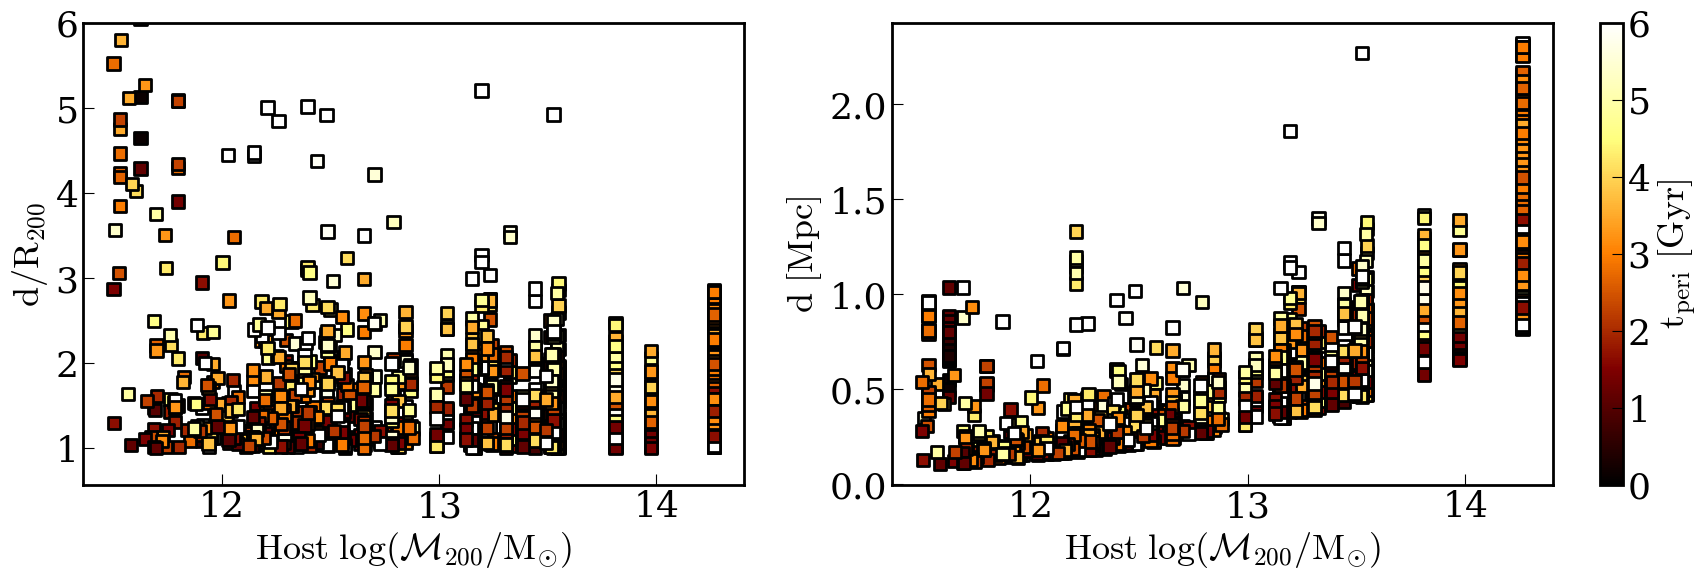

In [31]:
fig,ax=plt.subplots(1,4,figsize=(20,6),width_ratios=[0.49,0.01,0.49,0.01])

back_host = np.genfromtxt('backsplash.txt',usecols=0,dtype='int')
back_gal = np.genfromtxt('backsplash.txt',usecols=2,dtype='int')
back_dz0 = np.genfromtxt('backsplash.txt',usecols=3,dtype='float')
back_peri = np.genfromtxt('backsplash.txt',usecols=4,dtype='float')
back_snap = np.genfromtxt('backsplash.txt',usecols=5,dtype='int')

bklg,llg_int,bkg_int = np.intersect1d(llg_a, back_gal, return_indices=True)
print(len(back_gal),len(bklg))

snap_z = np.genfromtxt('snap_z_age.txt',usecols=1)
snap_tl = np.genfromtxt('snap_z_age.txt',usecols=3)

back_llh,back_mem = np.unique(back_host,return_inverse=True)
Nunc = len(back_llh)
print(Nunc)

tperi = []
#back_arr = np.zeros((Nunc,2))
for l in range(Nunc): 
    lg = back_gal[np.where(l==back_mem)[0]]
    lp = back_dz0[np.where(l==back_mem)[0]]
    ltl = back_snap[np.where(l==back_mem)[0]]

    lgm200 = gls.hst.group_m200[gls.sub.SubhaloGrNr[lg]]
    lselc = np.where((gls.sub.mst[lg]>=7.5)&(gls.sub.mst[lg]<9.5)&(lgm200>=9))[0]
   
    #back_arr[l,:]=gls.hst.group_m200[back_llh[l]],len(back_mst)
    tperi.extend(snap_tl[ltl[lselc]])
   
    ax[0].scatter(gls.hst.group_m200[back_llh[l]]*np.ones(len(lselc)),lp[lselc]/gls.hst.Group_R_Crit200[back_llh[l]],s=80,c=snap_tl[ltl[lselc]],cmap=mcm.afmhot,vmin=0,vmax=6,edgecolors='black',marker='s',linewidth=2)
    ax[2].scatter(gls.hst.group_m200[back_llh[l]]*np.ones(len(lselc)),1e-3*lp[lselc],s=80,c=snap_tl[ltl[lselc]],cmap=mcm.afmhot,vmin=0,vmax=6,edgecolors='black',marker='s',linewidth=2)

print(min(tperi),np.median(tperi),max(tperi))

ax[1].set_axis_off()
ax[3].set_axis_off()
ax[0].set_ylim(top=6)
ax[0].set_xlabel(r'$Host\ log(\mathcal{M}_{200}/M_{\odot})$',fontsize=26)
ax[2].set_xlabel(r'$Host\ log(\mathcal{M}_{200}/M_{\odot})$',fontsize=26)

ax[0].set_ylabel(r'$d/R_{200}$',fontsize=26)
ax[2].set_ylabel(r'$d\ [Mpc]$',fontsize=26)

fig.colorbar(mcm.ScalarMappable(norm=mcol.Normalize(vmin=0, vmax=6),cmap=mcm.afmhot), ax=ax[3], orientation='vertical',fraction=2.5,label=r'$t_{\rm peri}\ [Gyr]$')

plt.savefig('Bbacksplash_convol.pdf',bbox_inches='tight')


5001
1290
1257


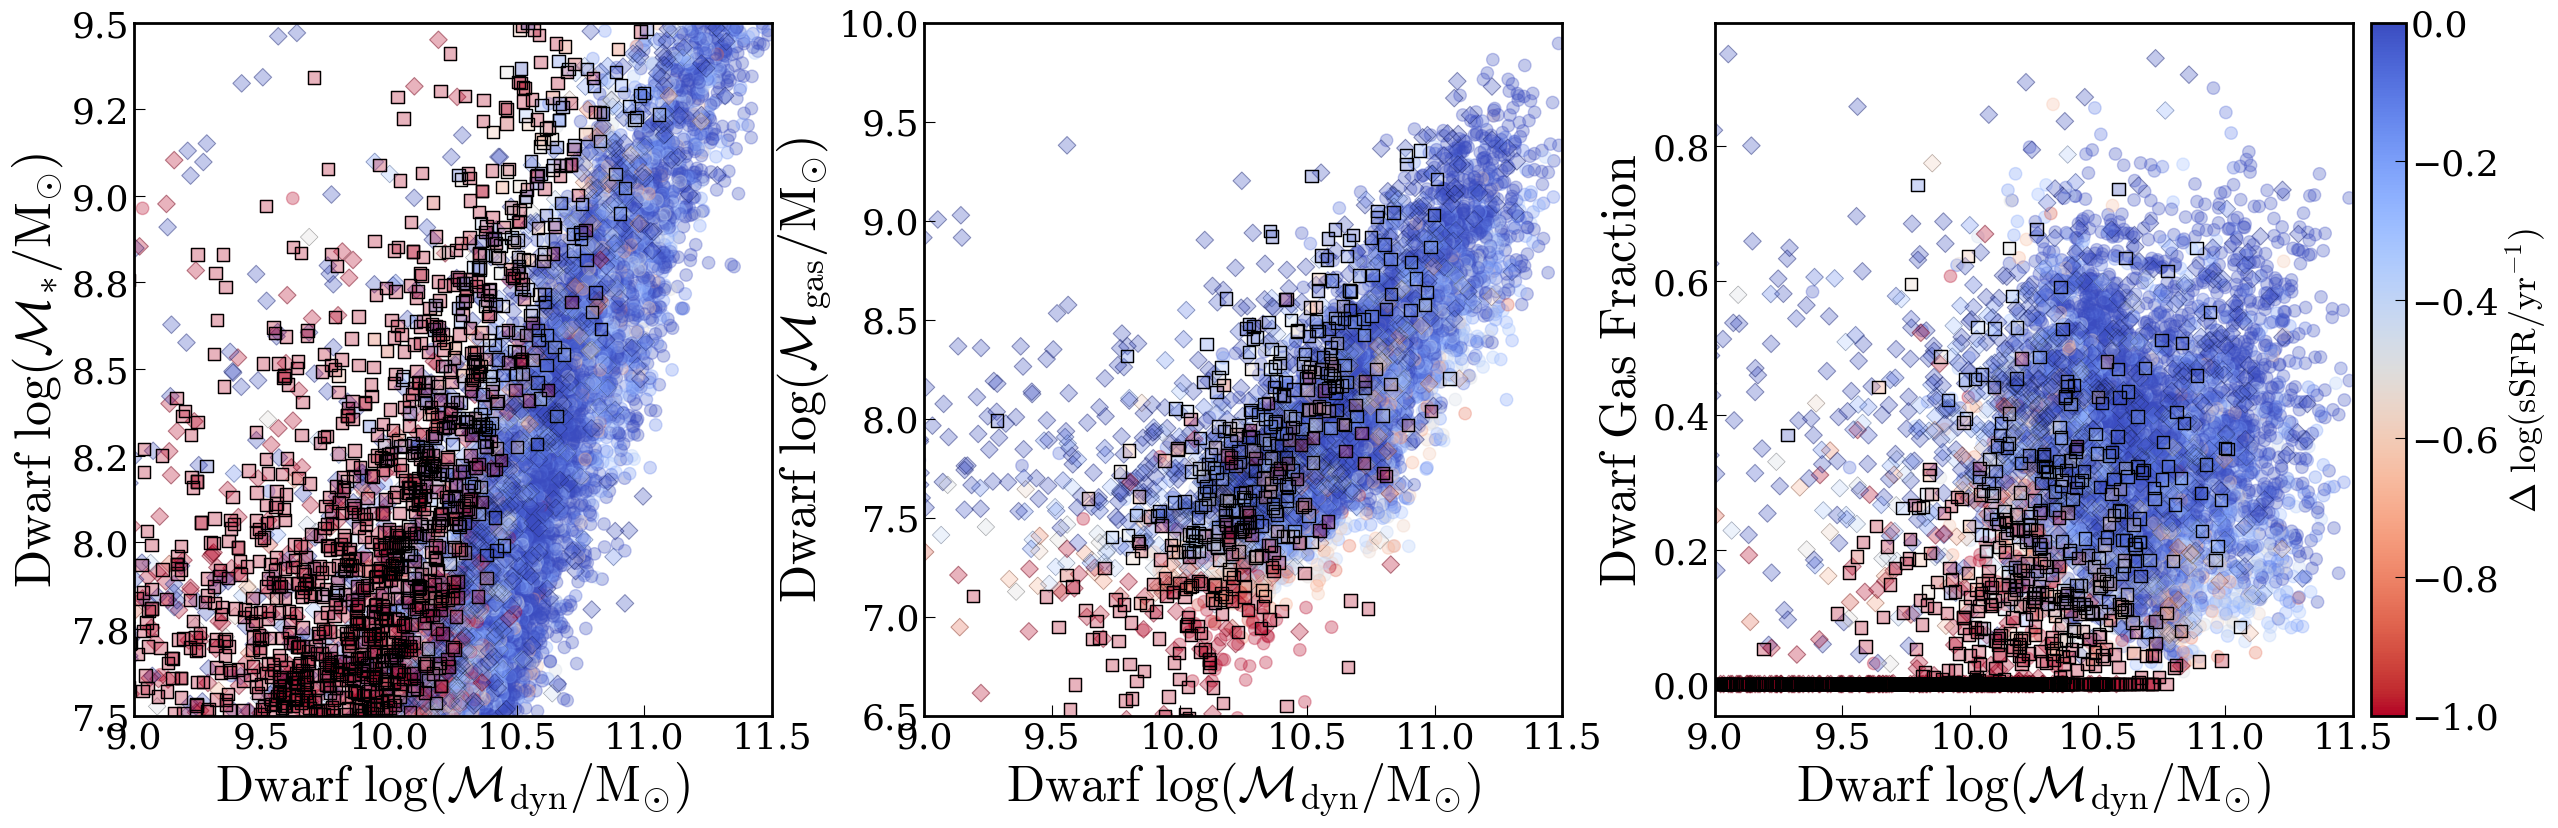

In [12]:
fig,ax=plt.subplots(1,6,figsize=(30,9),sharex=True,width_ratios=[0.32,0.01,0.32,0.01,0.32,0.02])

#dhst_bins = np.linspace(np.log10(0.15),np.log10(15),6)

for k in range(3):    
    outhl_b = np.array(llg[k])[np.where(((gls.hst.group_m200[llh[k]]<11.5)|((gls.hst.group_m200[llh[k]]>=11.5)&(np.array(x200[k])>=1)))&(gls.sub.mst[llg[k]]<9.5))[0]]
    print(len(outhl_b))
    mst_b = np.array([m for m in gls.sub.mst[outhl_b]])
    mgas_b = np.array([m for m in gls.sub.mgas[outhl_b]])
    #llh_b = np.array([gls.hst.group_m200[h] for h in llh[k]])
    llh_b = 10.155 + np.log10( np.array([gls.sub.SubhaloMass[h] for h in outhl_b]))
    gas_frac = np.power(10,mgas_b)/(np.power(10,mgas_b)+np.power(10,mst_b))

    ssfr_b = np.array([s for s in gls.sub.ssfr[outhl_b]])
    dsfms_b = ssfr_b-(sfms_intercept + sfms_slope*np.array(mst_b))

    ax[0].scatter(llh_b,mst_b,c=dsfms_b,cmap=mcm.coolwarm_r,vmin=-1, vmax=0,alpha=0.3,marker=bin_mk[k],s=80) 
    ax[2].scatter(llh_b,mgas_b,c=dsfms_b,cmap=mcm.coolwarm_r,vmin=-1, vmax=0,alpha=0.3,marker=bin_mk[k],s=80) 
    ax[4].scatter(llh_b,gas_frac,c=dsfms_b,cmap=mcm.coolwarm_r,vmin=-1, vmax=0,alpha=0.3,marker=bin_mk[k],s=80) 

    if k==1:
        ax[0].scatter(llh_b,mst_b,c='none',edgecolors='black',marker=bin_mk[k],linewidth=0.25,alpha=0.5,s=80)  
        ax[2].scatter(llh_b,mgas_b,c='none',edgecolors='black',marker=bin_mk[k],linewidth=0.25,alpha=0.5,s=80)  
        ax[4].scatter(llh_b,gas_frac,c='none',edgecolors='black',marker=bin_mk[k],linewidth=0.25,alpha=0.5,s=80)   


    if k==2:
        ax[0].scatter(llh_b,mst_b,c='none',edgecolors='black',marker=bin_mk[k],linewidth=1,s=80) 
        ax[2].scatter(llh_b,mgas_b,c='none',edgecolors='black',marker=bin_mk[k],linewidth=1,s=80) 
        ax[4].scatter(llh_b,gas_frac,c='none',edgecolors='black',marker=bin_mk[k],linewidth=1,s=80)  

for j in [0,2,4]:
    ax[j].set_xlabel(r'$Dwarf\ log(\mathcal{M}_{dyn}/M_{\odot})$',fontsize=36)
    ax[j].xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:.1f}"))


ax[0].set_xlim((9,11.5))
ax[0].set_ylim((7.5,9.5))
ax[2].set_ylim((6.5,10))
ax[5].set_ylim((1e-2,1))
      
#ax[0].plot(mhalo_bin,most(mhalo_bin),lw=3,ls='--',color='black')
#ax[2].plot(mhalo_bin,bradf(mhalo_bin),lw=3,ls='--',color='black')
#ax[0].plot(mhalo_bin,behroozi(mhalo_bin),lw=3,ls=':',color='black')
ax[5].set_yscale('log')
ax[1].set_axis_off()
ax[3].set_axis_off()
ax[5].set_axis_off()

fig.colorbar(mcm.ScalarMappable(norm=mcol.Normalize(vmin=-1, vmax=0),cmap=mcm.coolwarm_r), ax=ax[5], orientation='vertical',fraction=2.2,label=r'$\Delta\ log(sSFR/yr^{-1})$')

ax[4].set_ylabel(r'$Dwarf\ Gas\ Fraction$',fontsize=36)
ax[2].set_ylabel(r'$Dwarf\ log(\mathcal{M}_{gas}/M_{\odot})$',fontsize=36)
ax[0].set_ylabel(r'$Dwarf\ log(\mathcal{M}_{\ast}/M_{\odot})$',fontsize=36)
ax[0].yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:.1f}"))


ax[0].set_rasterized(True)
ax[2].set_rasterized(True)
plt.subplots_adjust(wspace=0.2)
plt.savefig('Bgroup_shmr_count.pdf',bbox_inches='tight')

In [26]:
print(min(llr_a[dw_samp]),max(llr_a[dw_samp]),np.median(llr_a[dw_samp]))
print(min(dhost_a[dw_samp]),max(dhost_a[dw_samp]),np.median(dhost_a[dw_samp]))
print(min(llt_a[dw_samp]),max(llt_a[dw_samp]),np.median(llt_a[dw_samp]))

-1.4305908069815438 6.392237014836915 0.8053182555225471
0.004623131403160965 10.398552974114022 1.2701285816619805
-2.3933797461182316 8.1809277525008 0.6072955252414056


In [27]:
dsfms_a = ssfr_a[dw_samp]-(sfms_intercept -1 + sfms_slope*np.array(mst_a[dw_samp]))
red = dw_samp[np.where(dsfms_a<0)[0]]
blue = dw_samp[np.where(dsfms_a>=0)[0]]

print('Overall QF:',100*len(red)/(len(red)+len(blue)))

#print(len(dw_samp),len(red),len(blue))
print('dhost field QF:',100*len(np.where(dhost_a[red]>=1.5)[0])/(len(np.where(dhost_a[red]>=1.5)[0])+len(np.where(dhost_a[blue]>=1.5)[0])))
print('theta1 field QF:',100*len(np.where(llt_a[red]<0)[0])/(len(np.where(llt_a[red]<0)[0])+len(np.where(llt_a[blue]<0)[0])))

print(len(np.where(dhost_a[red]<1.5)[0])/len(red),len(np.where(llt_a[red]>=0)[0])/len(red))
print(len(np.where(dhost_a[blue]>=1.5)[0])/len(blue),len(np.where(llt_a[blue]<0)[0])/len(blue))

Overall QF: 17.656765676567655
dhost field QF: 1.2357120790855731
theta1 field QF: 1.1914893617021276
0.9688473520249221 0.9781931464174455
0.5339011356045424 0.3877755511022044


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


0 0.055055775458798126
1 0.04946236559139785
2 0.7597454256165473


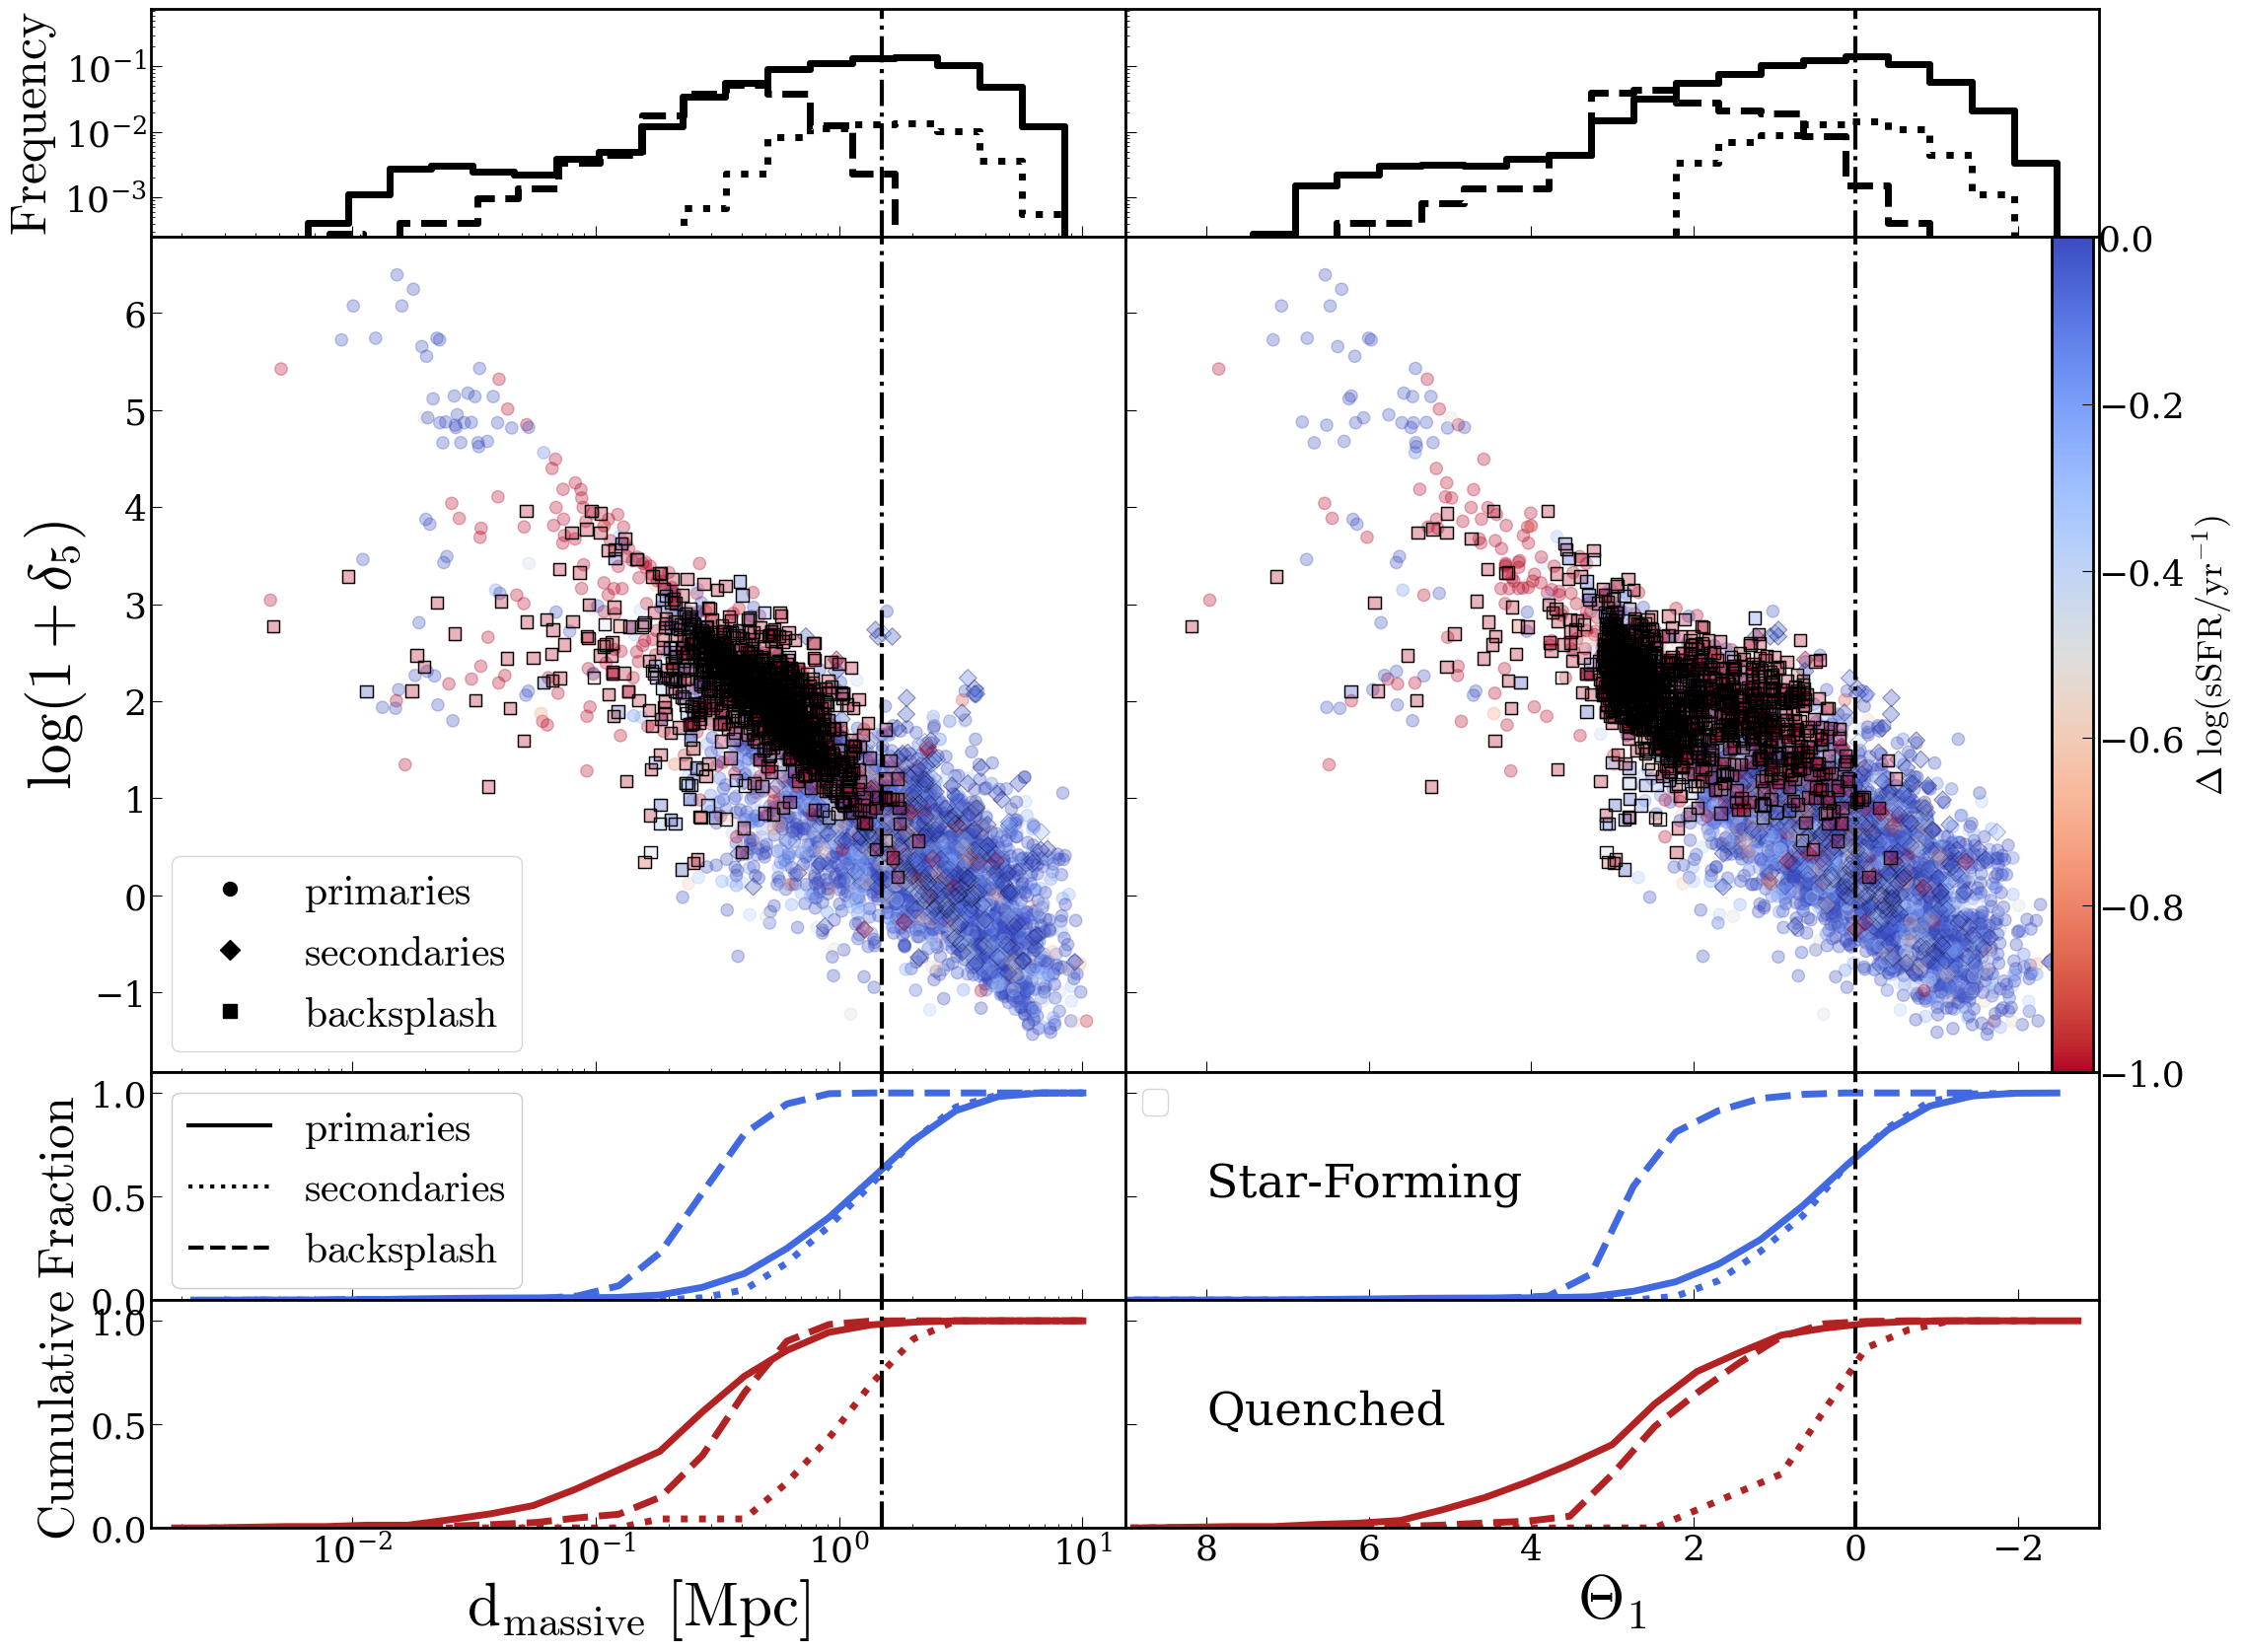

In [19]:
fig,ax=plt.subplots(4,3,figsize=(26,20),sharey='row',sharex='col',width_ratios=[0.49,0.49,0.02],height_ratios=[0.15,0.55,0.15,0.15])

tracer_bins1 = [np.logspace(np.log10(0.0015),np.log10(15),24),np.linspace(-3,9,24)]
tracer_bw1 = [0.5*(tb[1]-tb[0]) for tb in tracer_bins1]
bin_ls = ['-',':','--']


ax[2,1].legend(loc='best',fontsize=24,framealpha=0.8,frameon=True)

for k in range(3):
    llt_b = np.array([t for t in llt[k]])
    dhost_b = np.array([d for d in dhost[k]])
    llr_b = np.log10(np.array([r for r in llr[k]])) - np.log10(0.142904)

    bin_sat, bin_edg = np.histogram(dhost_b,bins=tracer_bins1[0])
    ax[0,0].step(tracer_bins1[0][:-1]+tracer_bw1[0],bin_sat/np.sum(N_lll),color='black',ls=bin_ls[k],lw=5,where='mid')

    bin_sat, bin_edg = np.histogram(llt_b,bins=tracer_bins1[1])
    ax[0,1].step(tracer_bins1[1][:-1]+tracer_bw1[1],bin_sat/np.sum(N_lll),color='black',ls=bin_ls[k],lw=5,where='mid')
    
    ssfr_b = np.array([s for s in gls.sub.ssfr[llg[k]]])
    mst_b = np.array([m for m in gls.sub.mst[llg[k]]])
    dsfms_b = ssfr_b-(sfms_intercept + sfms_slope*np.array(mst_b))
    red = np.where(dsfms_b<-1)[0]
    blue = np.where(dsfms_b>=-1)[0]
    print(k,len(red)/(len(red)+len(blue)))

    bin_sat, bin_edg = np.histogram(dhost_b,bins=tracer_bins1[0])
    ax[0,0].step(tracer_bins1[0][:-1]+tracer_bw1[0],bin_sat/np.sum(N_lll),color='black',ls=bin_ls[k],lw=5,where='mid')

    bin_sat, bin_edg = np.histogram(llt_b,bins=tracer_bins1[1])
    ax[0,1].step(tracer_bins1[1][:-1]+tracer_bw1[1],bin_sat/np.sum(N_lll),color='black',ls=bin_ls[k],lw=5,where='mid')

    ax[1,0].scatter(dhost_b,llr_b,c=dsfms_b,cmap=mcm.coolwarm_r,vmin=-1, vmax=0,alpha=0.3,marker=bin_mk[k],s=80)
    ax[1,1].scatter(llt_b,llr_b,c=dsfms_b,cmap=mcm.coolwarm_r,vmin=-1, vmax=0,alpha=0.3,marker=bin_mk[k],s=80)

    if k==1:
        ax[1,0].scatter(dhost_b,llr_b,c='none',edgecolors='black',marker=bin_mk[k],linewidth=0.25,alpha=0.5,s=80) 
        ax[1,1].scatter(llt_b,llr_b,c='none',edgecolors='black',marker=bin_mk[k],linewidth=0.25,alpha=0.5,s=80) 

    if k==2:
        ax[1,0].scatter(dhost_b,llr_b,c='none',edgecolors='black',marker=bin_mk[k],linewidth=1,s=80) 
        ax[1,1].scatter(llt_b,llr_b,c='none',edgecolors='black',marker=bin_mk[k],linewidth=1,s=80)  


    bin_sat, bin_edg = np.histogram(dhost_b[red],bins=tracer_bins1[0])
    bin_edg+=0.5*(bin_edg[1]-bin_edg[0])
    bin_sat=np.cumsum(bin_sat)/len(red)
    #print(bin_sat)
    ax[3,0].plot(bin_edg[:-1],bin_sat,color='firebrick',lw=5,ls=bin_ls[k])
    
    bin_sat, bin_edg = np.histogram(dhost_b[blue],bins=tracer_bins1[0])
    bin_edg+=0.5*(bin_edg[1]-bin_edg[0])
    bin_sat=np.cumsum(bin_sat)/len(blue)
    #print(bin_sat)
    ax[2,0].plot(bin_edg[:-1],bin_sat,color='royalblue',lw=5,ls=bin_ls[k])
    
    bin_sat, bin_edg = np.histogram(llt_b[red],bins=tracer_bins1[1])
    bin_edg+=0.5*(bin_edg[1]-bin_edg[0])
    bin_sat=np.cumsum(bin_sat[::-1])[::-1]/len(red)
    #print(bin_sat)
    ax[3,1].plot(bin_edg[:-1],bin_sat,color='firebrick',lw=5,ls=bin_ls[k])
    
    bin_sat, bin_edg = np.histogram(llt_b[blue],bins=tracer_bins1[1])
    bin_edg+=0.5*(bin_edg[1]-bin_edg[0])
    bin_sat=np.cumsum(bin_sat[::-1])[::-1]/len(blue)
    #print(bin_sat)
    ax[2,1].plot(bin_edg[:-1],bin_sat,color='royalblue',lw=5,ls=bin_ls[k])

    
#ax[0].scatter(dhost_a[dw_samp],llr_a[dw_samp],c=dsfms_a,cmap=mcm.coolwarm_r,vmin=-1, vmax=0,alpha=0.2,marker=binmk_a[dw_samp])
#ax[2].scatter(llt_a[dw_samp],llr_a[dw_samp],c=dsfms_a,cmap=mcm.coolwarm_r,vmin=-1, vmax=0,alpha=0.2,marker=binmk_a[dw_samp])

custom_lines = [Line2D([0], [0],lw=3,ls=bin_ls[0], color='black'), Line2D([0], [0],lw=3,ls=bin_ls[1], color='black'), Line2D([0], [0],lw=3,ls=bin_ls[2], color='black')]
leg=Legend(ax[2,0],custom_lines,[r'$primaries$',r'$secondaries$',r'$backsplash$'],loc='upper left',fontsize=30,frameon=True,framealpha=1.0)
ax[2,0].add_artist(leg)

custom_lines = [Line2D([0], [0],lw=3,ls='none',marker=bin_mk[0], color='black',markersize=10), Line2D([0], [0],lw=3,ls='none',marker=bin_mk[1], color='black',markersize=10), Line2D([0], [0],lw=3,ls='none',marker=bin_mk[2], color='black',markersize=10)]
leg=Legend(ax[1,0],custom_lines,[r'$primaries$',r'$secondaries$',r'$backsplash$'],loc='best',fontsize=30,framealpha=0.8,frameon=True)
ax[1,0].add_artist(leg)


ax[2,1].text(8,0.5,'Star-Forming',fontsize=34)
ax[3,1].text(8,0.5,'Quenched',fontsize=34)

#ax[0].set_xlim((7,9.5))
ax[1,0].set_ylabel(r'$log(1+\delta_5)$',fontsize=44)
ax[2,0].set_ylabel(r'$Fraction$',fontsize=36)
ax[3,0].set_ylabel(r'$Cumulative$',fontsize=36)
ax[3,1].set_xlabel(r'$\Theta_1$',fontsize=44)
ax[3,0].set_xlabel(r'$d_{massive}\ [Mpc]$',fontsize=44)
ax[0,0].set_ylabel(r'$Frequency$',fontsize=36)

ax[0,1].invert_xaxis()
ax[2,1].invert_xaxis()

for k in range(4):
    ax[k,0].set_xscale('log')
    ax[k,0].axvline(1.5,color='black',ls='-.',lw=3)
    ax[k,1].axvline(0,color='black',ls='-.',lw=3)
    ax[k,2].set_axis_off()

for k in range(2):
    #ax[0,k].set_axis_off()
    ax[0,k].set_yscale('log')
    ax[0,k].set_ylim(2.5e-4,0.75)
    #x[2,k].set_yscale('log')
    ax[2,k].set_ylim(0.0,1.1)
    ax[3,k].set_ylim(0.0,1.1)
    ax[1,k].set_rasterized(True)
    
ax[1,0].set_xlim((0.0015,15))
ax[1,1].set_xlim((9,-3))

fig.colorbar(mcm.ScalarMappable(norm=mcol.Normalize(vmin=-1, vmax=0),cmap=mcm.coolwarm_r), ax=ax[1,2], orientation='vertical',fraction=2.2,label=r'$\Delta\ log(sSFR/yr^{-1})$')
plt.subplots_adjust(wspace=0.0,hspace=0.0)
plt.savefig('Benv_dssfr.pdf',bbox_inches='tight')

In [63]:
bin_stellar = np.arange(9.5,11.5,0.2)

dg1 = massive_gal[np.where(gls.sub.ssfr[massive_gal]>-15)[0]]
bin_med, bin_edg, bin_n = sts.binned_statistic(gls.sub.mst[dg1],gls.sub.ssfr[dg1], statistic='median', bins=bin_stellar)

res = sts.linregress(bin_edg[:-1],bin_med)
print(res.intercept,res.slope)

-4.043278702457738 -0.620927639813141


0 1274 1298
1 4709 4685
All 0 dhost [0.06219673 0.32083947 0.18810657 0.02520697 0.        ]
All 0 tidal [       nan 0.00526086 0.04941279 0.22296692 0.25623365]
All 1 dhost [0.1700592  0.18909628 0.10337893 0.01197727 0.00367214]
All 1 tidal [0.         0.00589661 0.02816008 0.10392711 0.33274515]
0 1216 1267
1 4713 4662
No Backsplash 0 dhost [0.09573961 0.05521252 0.02051968 0.01262716 0.        ]
No Backsplash 0 tidal [       nan 0.00520187 0.0140782  0.07354769 0.07153574]
No Backsplash 1 dhost [0.07232121 0.054971   0.01984132 0.00352744 0.00442379]
No Backsplash 1 tidal [0.         0.00579701 0.0128365  0.04365961 0.09306089]


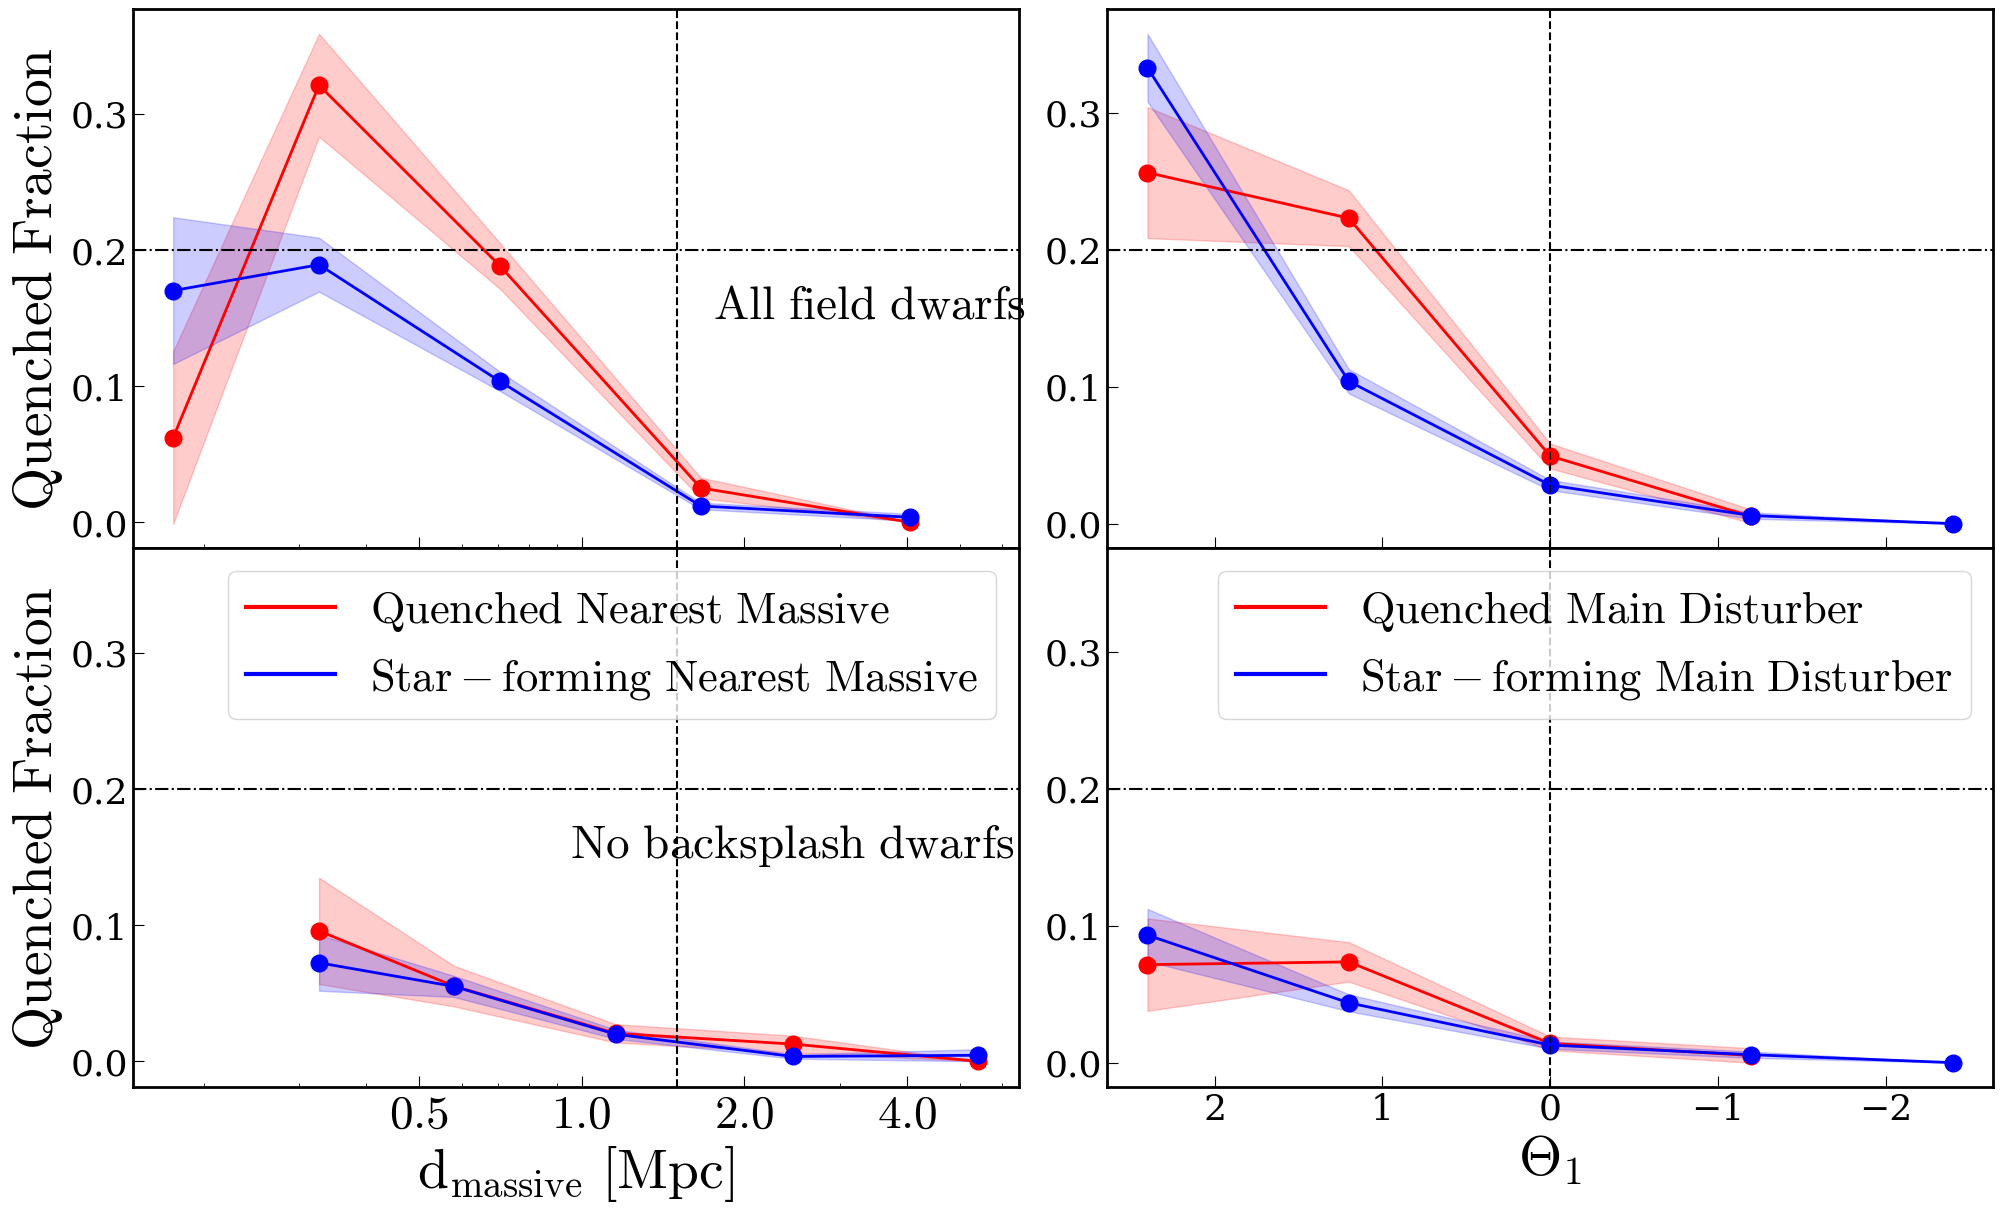

In [65]:
fig,ax=plt.subplots(2,2,figsize=(24,14),sharey='col',sharex='col')

bin_cols=['red','blue']
tracer_bins1 = [np.logspace(np.log10(0.1),np.log10(10),6),np.linspace(-3,3,6)]
tracer_bw1 = [0.5*(tb[1]-tb[0]) for tb in tracer_bins1]

Nbtsp = 1000

dhmd_ssfr = [gls.sub.ssfr[dhp_b]-(res.intercept -1 + res.slope*gls.sub.mst[dhp_b]),gls.sub.ssfr[mdb_b]-(res.intercept -1 + res.slope*gls.sub.mst[mdb_b])]
qsfhost = [np.where((dhmd_ssfr[0]<0)&(m200_b<11.5))[0],np.where((dhmd_ssfr[1]<0)&(m200_b<11.5))[0],np.where((dhmd_ssfr[0]>=0)&(m200_b<11.5))[0],np.where((dhmd_ssfr[1]>=0)&(m200_b<11.5))[0]]

boot_qnc = np.zeros((4,Nbtsp,5))
for j in range(2):
    print(j,len(qsfhost[2*j]),len(qsfhost[2*j+1]))
    for m in range(Nbtsp):
            boot = npr.choice(qsfhost[2*j],len(qsfhost[2*j]),replace=True)
    
            dhost_e = [dhost_b[i] for i in boot]
            mst_e = [gls.sub.mst[llg_b[i]] for i in boot]
            ssfr_e = [gls.sub.ssfr[llg_b[i]] for i in boot]
        
            qnc_e = 1-np.heaviside(ssfr_e-(sfms_intercept -1 + sfms_slope*np.array(mst_e)),1)
    
            bin_qnc, bin_edg, bin_n = sts.binned_statistic(dhost_e,qnc_e,statistic='mean', bins=tracer_bins1[0])
            boot_qnc[2*j,m,:] = bin_qnc

            boot = npr.choice(qsfhost[2*j+1],size=len(qsfhost[2*j+1]),replace=True)
    
            llt_e = np.array([llt_b[i] for i in boot])
            mst_e = [gls.sub.mst[llg_b[i]] for i in boot]
            ssfr_e = [gls.sub.ssfr[llg_b[i]] for i in boot]
        
            qnc_e = 1-np.heaviside(ssfr_e-(sfms_intercept -1 + sfms_slope*np.array(mst_e)),1)

            bin_qnc, bin_edg, bin_n = sts.binned_statistic(llt_e,qnc_e,statistic='mean', bins=tracer_bins1[1])
            boot_qnc[2*j+1,m,:] = bin_qnc
        
for j in range(2):
    boot_val = np.mean(boot_qnc[2*j,:,:],axis=0)
    boot_err = np.std(boot_qnc[2*j,:,:],axis=0,ddof=1)

    print('All',j,'dhost',boot_val)

    ax[0,0].plot(tracer_bins1[0][:-1]+tracer_bw1[0],boot_val,lw=2,marker=bin_mk[0],color=bin_cols[j],markersize=12)
    ax[0,0].fill_between(tracer_bins1[0][:-1]+tracer_bw1[0],boot_val-boot_err,boot_val+boot_err,color=bin_cols[j],alpha=0.2)

    boot_val = np.mean(boot_qnc[2*j+1,:,:],axis=0)
    boot_err = np.std(boot_qnc[2*j+1,:,:],axis=0,ddof=1)

    print('All',j,'tidal',boot_val)

    ax[0,1].plot(tracer_bins1[1][:-1]+tracer_bw1[1],boot_val,lw=2,marker=bin_mk[0],color=bin_cols[j],markersize=12)
    ax[0,1].fill_between(tracer_bins1[1][:-1]+tracer_bw1[1],boot_val-boot_err,boot_val+boot_err,color=bin_cols[j],alpha=0.2)

tracer_bins1 = [np.logspace(np.log10(0.2),np.log10(12),6),np.linspace(-3,3,6)]
tracer_bw1 = [0.5*(tb[1]-tb[0]) for tb in tracer_bins1]

dhmd_ssfr = [gls.sub.ssfr[dhp_d]-(res.intercept -1 + res.slope*gls.sub.mst[dhp_d]),gls.sub.ssfr[mdb_d]-(res.intercept -1 + res.slope*gls.sub.mst[mdb_d])]
qsfhost = [np.where((dhmd_ssfr[0]<0)&(m200_d<11.5))[0],np.where((dhmd_ssfr[1]<0)&(m200_d<11.5))[0],np.where((dhmd_ssfr[0]>=0)&(m200_d<11.5))[0],np.where((dhmd_ssfr[1]>=0)&(m200_d<11.5))[0]]

boot_qnc = np.zeros((4,Nbtsp,5))
for j in range(2):
    print(j,len(qsfhost[2*j]),len(qsfhost[2*j+1]))
    for m in range(Nbtsp):
            boot = npr.choice(qsfhost[2*j],len(qsfhost[2*j]),replace=True)
    
            dhost_f = [dhost_d[i] for i in boot]
            mst_f = [gls.sub.mst[llg_d[i]] for i in boot]
            ssfr_f = [gls.sub.ssfr[llg_d[i]] for i in boot]
        
            qnc_f = 1-np.heaviside(ssfr_f-(sfms_intercept -1 + sfms_slope*np.array(mst_f)),1)
    
            bin_qnc, bin_edg, bin_n = sts.binned_statistic(dhost_f,qnc_f,statistic='mean', bins=tracer_bins1[0])
            boot_qnc[2*j,m,:] = bin_qnc

            boot = npr.choice(qsfhost[2*j+1],size=len(qsfhost[2*j+1]),replace=True)
    
            llt_f = np.array([llt_d[i] for i in boot])
            mst_f = [gls.sub.mst[llg_d[i]] for i in boot]
            ssfr_f = [gls.sub.ssfr[llg_d[i]] for i in boot]
        
            qnc_f = 1-np.heaviside(ssfr_f-(sfms_intercept -1 + sfms_slope*np.array(mst_f)),1)

            bin_qnc, bin_edg, bin_n = sts.binned_statistic(llt_f,qnc_f,statistic='mean', bins=tracer_bins1[1])
            boot_qnc[2*j+1,m,:] = bin_qnc
        
for j in range(2):
    boot_val = np.mean(boot_qnc[2*j,:,:],axis=0)
    boot_err = np.std(boot_qnc[2*j,:,:],axis=0,ddof=1)

    print('No Backsplash',j,'dhost',boot_val)

    ax[1,0].plot(tracer_bins1[0][:-1]+tracer_bw1[0],boot_val,lw=2,marker=bin_mk[0],color=bin_cols[j],markersize=12)
    ax[1,0].fill_between(tracer_bins1[0][:-1]+tracer_bw1[0],boot_val-boot_err,boot_val+boot_err,color=bin_cols[j],alpha=0.2)

    boot_val = np.mean(boot_qnc[2*j+1,:,:],axis=0)
    boot_err = np.std(boot_qnc[2*j+1,:,:],axis=0,ddof=1)

    print('No Backsplash',j,'tidal',boot_val)

    ax[1,1].plot(tracer_bins1[1][:-1]+tracer_bw1[1],boot_val,lw=2,marker=bin_mk[0],color=bin_cols[j],markersize=12)
    ax[1,1].fill_between(tracer_bins1[1][:-1]+tracer_bw1[1],boot_val-boot_err,boot_val+boot_err,color=bin_cols[j],alpha=0.2)


    for k in range(2):
        ax[j,k].axhline(0.2,color='black',ls='-.')

    ax[j,0].axvline(1.5,color='black',ls='--')
    ax[j,1].axvline(0,color='black',ls='--')

    ax[j,0].set_ylabel(r'$Quenched\ Fraction$',fontsize=40)
#ax[0].set_ylabel(r'$Quenching\ Efficiency$',fontsize=30)

ax[0,0].set_xscale('log')
ax[1,0].set_xscale('log')
ax[1,0].set_xlabel(r'$d_{massive}\ [Mpc]$',fontsize=40)
ax[1,1].set_xlabel(r'$\Theta_1$',fontsize=40)
ax[0,1].invert_xaxis()
xticks = [0.5,1.0, 2,4]
xlabels = [f'${x:1.1f}$' for x in xticks]
ax[1,0].set_xticks(xticks, labels=xlabels,fontsize=34)

ax[0,0].text(1.75,0.15,r'$All\ field\ dwarfs$',fontsize=34)
ax[1,0].text(0.95,0.15,r'$No\ backsplash\ dwarfs$',fontsize=34)

custom_lines = [Line2D([0], [0],lw=3, color='red'), Line2D([0], [0],lw=3, color='blue')]
leg=Legend(ax[1,0],custom_lines,[r'$Quenched\ Nearest\ Massive$',r'$Star-forming\ Nearest\ Massive$'],loc='best',fontsize=32,framealpha=0.8,frameon=True)
ax[1,0].add_artist(leg)

custom_lines = [Line2D([0], [0],lw=3, color='red'), Line2D([0], [0],lw=3, color='blue')]
leg=Legend(ax[1,1],custom_lines,[r'$Quenched\ Main\ Disturber$',r'$Star-forming\ Main\ Disturber$'],loc='best',fontsize=32,framealpha=0.8,frameon=True)
ax[1,1].add_artist(leg)

plt.subplots_adjust(wspace=0.1,hspace=0.0)
plt.savefig('Bquench_conformity.pdf',bbox_inches='tight')


274 5558
18 465
911 1257


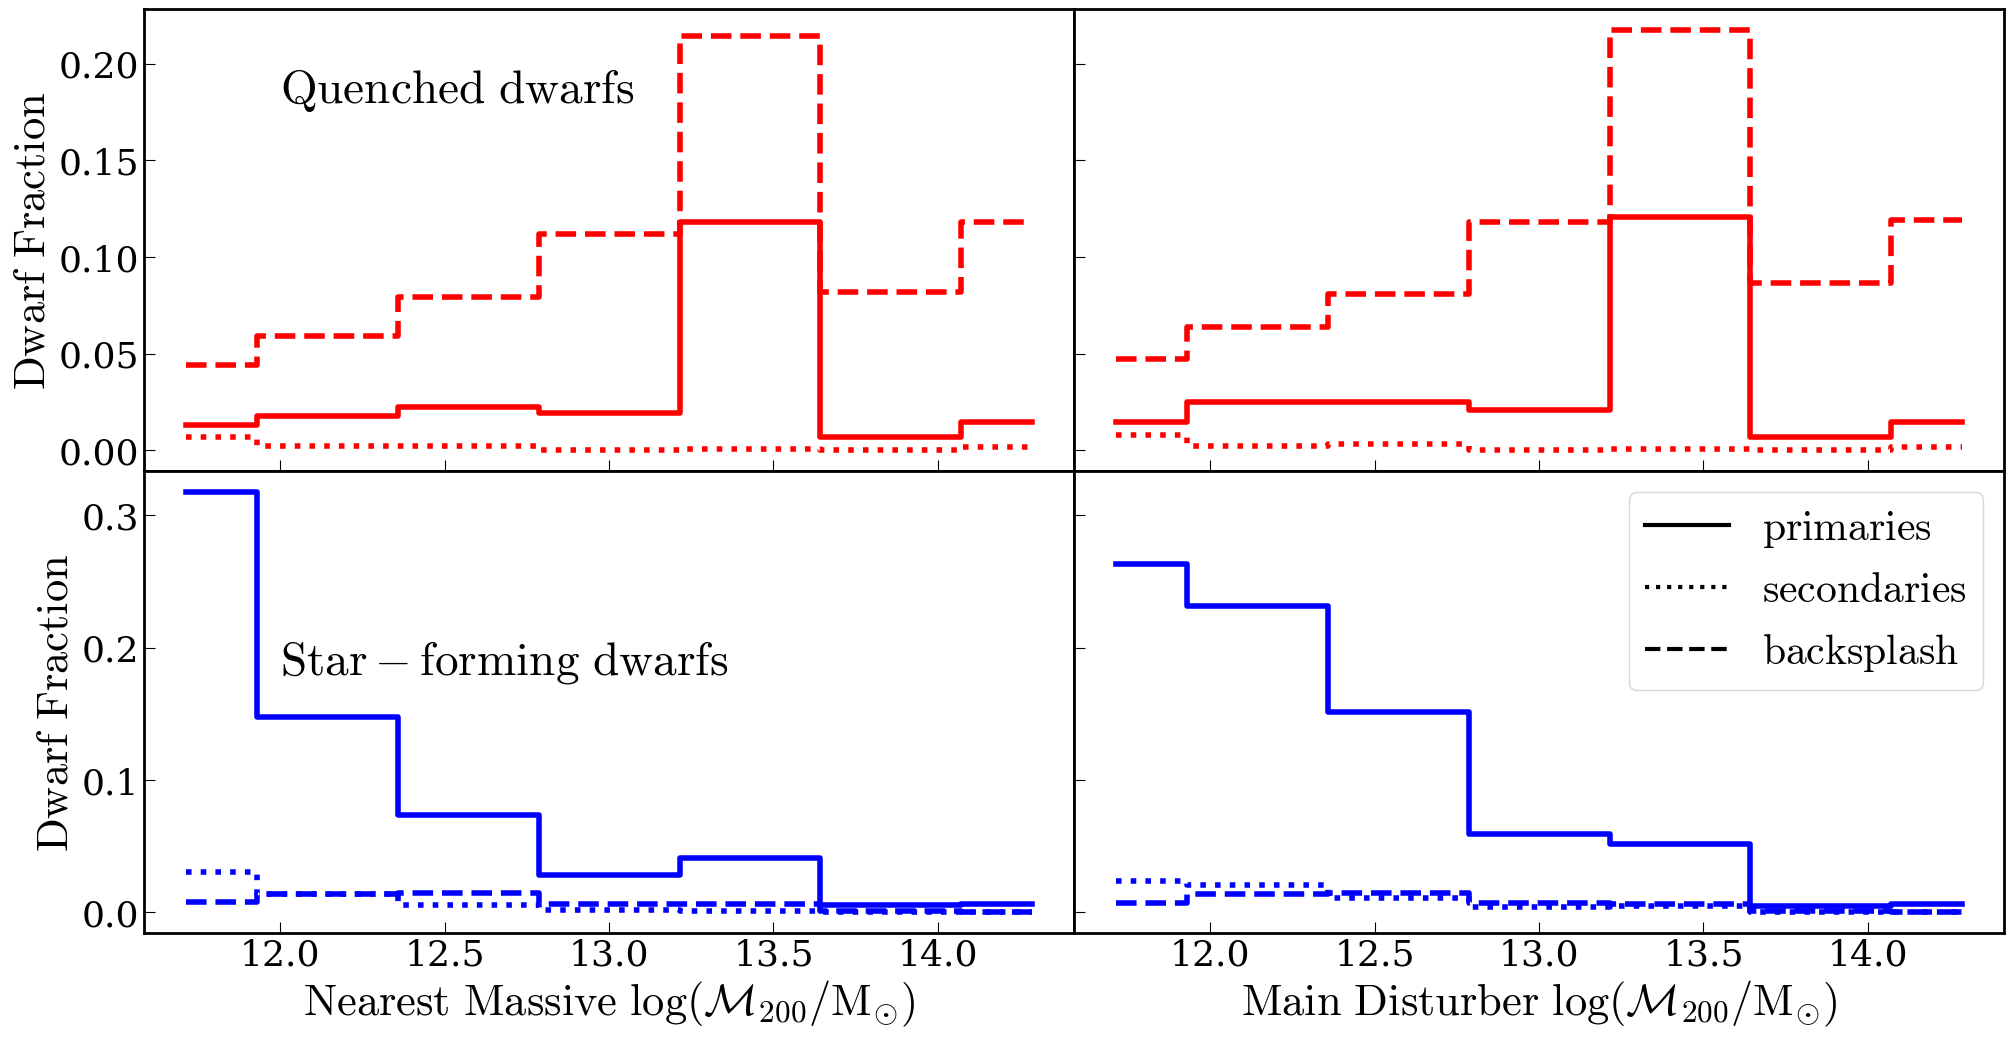

In [23]:
fig,ax=plt.subplots(2,2,figsize=(24,12),sharex='col',sharey='row')

bin_ls = ['-',':','--']
mh_bins = np.linspace(11.5,14.5,8)
mh_bw = 0.5*(mh_bins[1]-mh_bins[0])

qnc_a = ssfr_a-(sfms_intercept -1 + sfms_slope*mst_a)
red_a = np.where(qnc_a<0)[0]
blue_a = np.where(qnc_a>=0)[0]

for k in range(3):
    mst_b = np.array(gls.sub.mst[llg[k]])
    ssfr_b = np.array(gls.sub.ssfr[llg[k]])
    m200_b = gls.hst.group_m200[llh[k]]
    qnc_b  = ssfr_b-(sfms_intercept -1 + sfms_slope*np.array(mst_b))
    
    red = np.where(qnc_b<0)[0]
       
    m200_dhp = gls.hst.group_m200[gls.sub.SubhaloGrNr[dhp[k]][red]]
    m200_mdb = gls.hst.group_m200[gls.sub.SubhaloGrNr[mdb[k]][red]]
    
    bin_sat, bin_edg = np.histogram(m200_dhp,bins=mh_bins)
    print(np.sum(bin_sat),N_lll[k])
    ax[0,0].step(bin_edg[:-1]+mh_bw,bin_sat/len(red_a),color='red',ls=bin_ls[k],lw=4,where='mid')

    bin_sat, bin_edg = np.histogram(m200_mdb,bins=mh_bins)
    ax[0,1].step(bin_edg[:-1]+mh_bw,bin_sat/len(red_a),color='red',ls=bin_ls[k],lw=4,where='mid')

    blue = np.where(qnc_b>0)[0]
       
    m200_dhp = gls.hst.group_m200[gls.sub.SubhaloGrNr[dhp[k]][blue]]
    m200_mdb = gls.hst.group_m200[gls.sub.SubhaloGrNr[mdb[k]][blue]]
    
    bin_sat, bin_edg = np.histogram(m200_dhp,bins=mh_bins)
    ax[1,0].step(bin_edg[:-1]+mh_bw,bin_sat/len(blue_a),color='blue',ls=bin_ls[k],lw=4,where='mid')

    bin_sat, bin_edg = np.histogram(m200_mdb,bins=mh_bins)
    ax[1,1].step(bin_edg[:-1]+mh_bw,bin_sat/len(blue_a),color='blue',ls=bin_ls[k],lw=4,where='mid')

custom_lines = [Line2D([0], [0],lw=3,ls=bin_ls[0], color='black'), Line2D([0], [0],lw=3,ls=bin_ls[1], color='black'), Line2D([0], [0],lw=3,ls=bin_ls[2], color='black')]
leg=Legend(ax[1,1],custom_lines,[r'$primaries$',r'$secondaries$',r'$backsplash$'],loc='best',fontsize=30,framealpha=0.8,frameon=True)
ax[1,1].add_artist(leg)

ax[0,0].set_ylabel(r'$Dwarf\ Fraction$',fontsize=32)
ax[1,0].set_ylabel(r'$Dwarf\ Fraction$',fontsize=32)

ax[1,0].set_xlabel(r'$Nearest\ Massive\ log(\mathcal{M}_{200}/M_{\odot})$',fontsize=32)
ax[1,1].set_xlabel(r'$Main\ Disturber\ log(\mathcal{M}_{200}/M_{\odot})$',fontsize=32)

ax[0,0].text(12,0.18,r'$Quenched\ dwarfs$',fontsize=34)
ax[1,0].text(12,0.18,r'$Star-forming\ dwarfs$',fontsize=34)

plt.subplots_adjust(wspace=0.0,hspace=0.0)
plt.savefig('Bquench_mneigh.pdf',bbox_inches='tight')

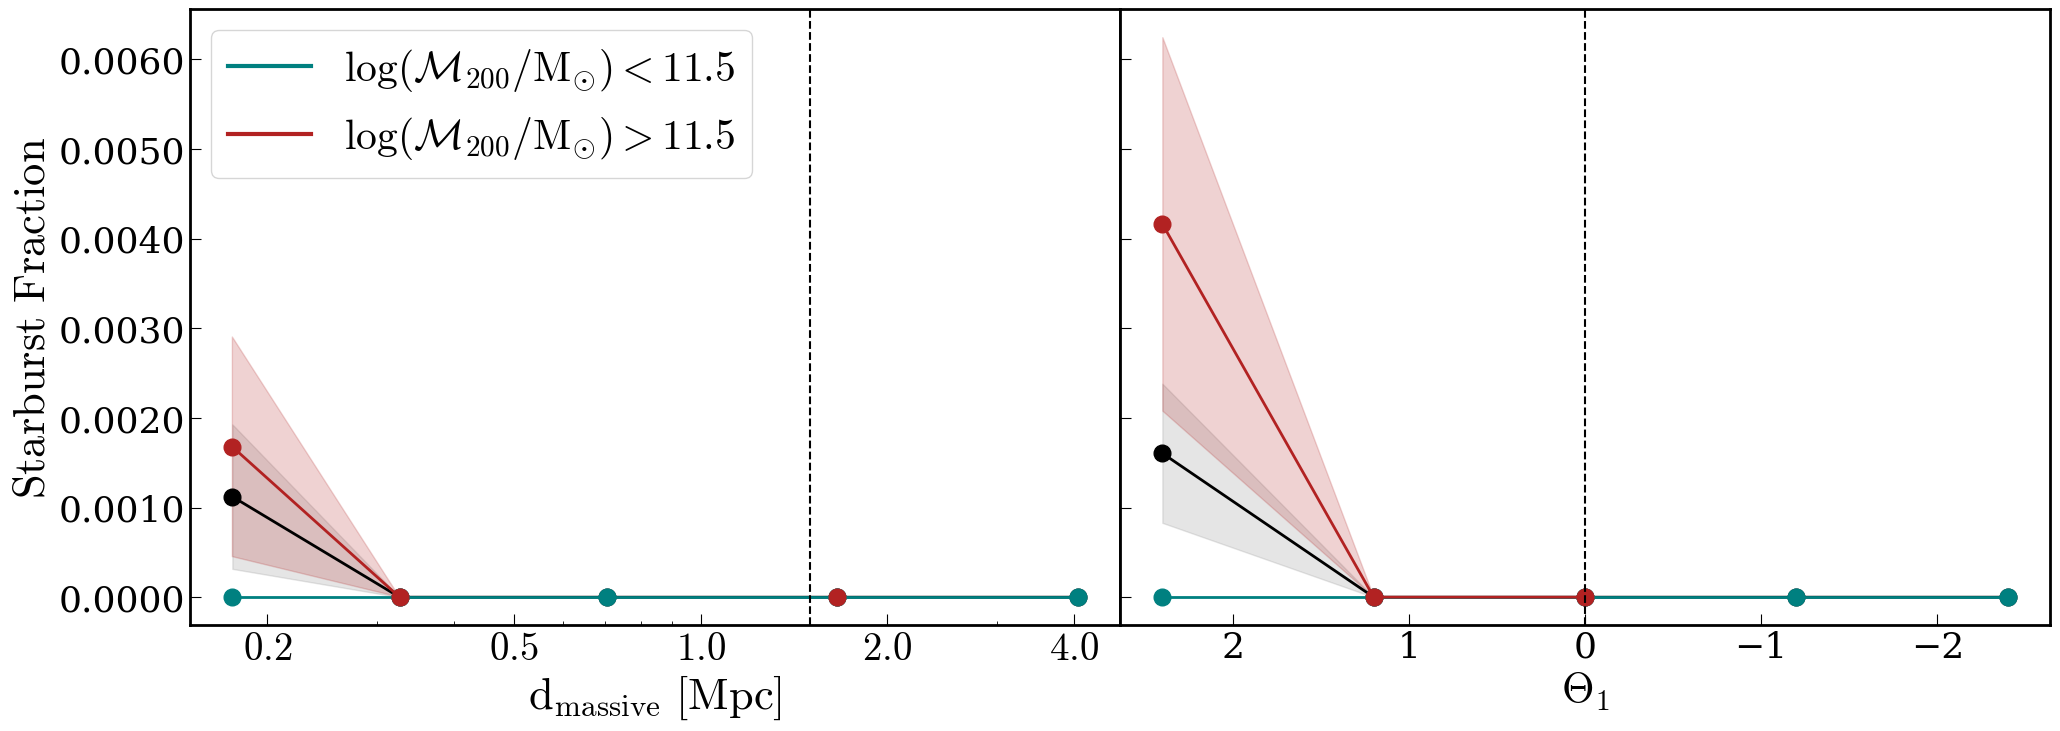

In [16]:
fig,ax=plt.subplots(1,2,figsize=(24,8),sharey=True)
bin_cols = ['teal','firebrick']

#dsfr_bins = np.linspace(0,2,9)
#dsfr_bw = 0.5*(dsfr_bins[1]-dsfr_bins[0])
Nbtsp = 1000

tracer_bins = [np.logspace(np.log10(0.1),np.log10(10),6),np.linspace(-3,3,6)]
tracer_bw = [0.5*(tb[1]-tb[0]) for tb in tracer_bins]

boot_qnc = np.zeros((2,Nbtsp,5))
for m in range(Nbtsp):
            boot = npr.choice(range(np.sum(N_lll)),size=np.sum(N_lll),replace=True)

            dhost_b = [dhost_a[i] for i in boot]
            llt_b = np.array([llt_a[i] for i in boot])
            #llh_b = np.array([llh[i] for i in boot for m in range(llm[i])])
        
            mst_b = [mst_a[i] for i in boot]
            ssfr_b = [ssfr_a[i] for i in boot]
        
            dsfms_b = ssfr_b-(sfms_intercept + sfms_slope*np.array(mst_b))
            qnc_b = np.heaviside(ssfr_b-(sfms_intercept +1 + sfms_slope*np.array(mst_b)),1)
    
            bin_all, bin_edg,_ = sts.binned_statistic(dhost_b,qnc_b,bins=tracer_bins[0],statistic='mean')
            boot_qnc[0,m,:] = bin_all

            bin_all, bin_edg,_ = sts.binned_statistic(llt_b,qnc_b,bins=tracer_bins[1],statistic='mean')
            boot_qnc[1,m,:] = bin_all

for j in range(2):
    boot_val=np.mean(boot_qnc[j,:,:],axis=0)
    boot_err=np.std(boot_qnc[j,:,:],axis=0,ddof=1)
    
    ax[j].plot(tracer_bins[j][:-1]+tracer_bw[j],boot_val,lw=2,marker='o',color='black',markersize=12)
    ax[j].fill_between(tracer_bins[j][:-1]+tracer_bw[j],boot_val-boot_err,boot_val+boot_err,color='gray',alpha=0.2)

#tracer_bins1 = [np.logspace(np.log10(0.2),np.log10(12),5),np.linspace(-2,2,5)]
#tracer_bw1 = [0.5*(tb[1]-tb[0]) for tb in tracer_bins1]

for j in range(2):
    boot_qnc = np.zeros((2,Nbtsp,5))
    for m in range(Nbtsp):
            boot = npr.choice(host_bins[j],size=len(host_bins[j]),replace=True)
            dhost_b = [dhost_a[i] for i in boot]
            llt_b = np.array([llt_a[i] for i in boot])
            #llh_b = np.array([llh[i] for i in boot for m in range(llm[i])])
        
            mst_b = [mst_a[i] for i in boot]
            ssfr_b = [ssfr_a[i] for i in boot]
        
            dsfms_b = ssfr_b-(sfms_intercept + sfms_slope*np.array(mst_b))
            qnc_b = np.heaviside(ssfr_b-(sfms_intercept +1 + sfms_slope*np.array(mst_b)),1)
    
            bin_all, bin_edg,_ = sts.binned_statistic(dhost_b,qnc_b,bins=tracer_bins[0],statistic='mean')
            boot_qnc[0,m,:] = bin_all

            bin_all, bin_edg,_ = sts.binned_statistic(llt_b,qnc_b,bins=tracer_bins[1],statistic='mean')
            boot_qnc[1,m,:] = bin_all

    boot_val = np.mean(boot_qnc,axis=0)
    boot_err = np.std(boot_qnc,axis=0,ddof=1)
        
    for k in range(2):
        boot_val = np.mean(boot_qnc[k,:,:],axis=0)
        boot_err = np.std(boot_qnc[k,:,:],axis=0,ddof=1)
    
        ax[k].plot(tracer_bins[k][:-1]+tracer_bw[k],boot_val,lw=2,marker='o',color=bin_cols[j],markersize=12)
        ax[k].fill_between(tracer_bins[k][:-1]+tracer_bw[k],boot_val-boot_err,boot_val+boot_err,color=bin_cols[j],alpha=0.2)

ax[0].set_xscale('log')
ax[0].axvline(1.5,color='black',ls='--')
ax[1].axvline(0,color='black',ls='--')
ax[1].invert_xaxis()
ax[0].yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:.4f}"))
xticks = [0.2,0.5,1.0, 2,4]
xlabels = [f'${x:1.1f}$' for x in xticks]
ax[0].set_xticks(xticks, labels=xlabels,fontsize=28)

ax[0].set_ylabel(r'$Starburst\ Fraction$',fontsize=32)
#ax[0].set_ylabel(r'$Quenching\ Efficiency$',fontsize=30)
ax[0].set_xlabel(r'$d_{massive}\ [Mpc]$',fontsize=32)
ax[1].set_xlabel(r'$\Theta_1$',fontsize=30)

custom_lines = [Line2D([0], [0],lw=3, color=bin_cols[0]), Line2D([0], [0],lw=3, color=bin_cols[1])]
leg=Legend(ax[0],custom_lines,[r'$log(\mathcal{M}_{200}/ M_{\odot})< 11.5$',r'$log(\mathcal{M}_{200}/ M_{\odot})> 11.5$'],loc='best',fontsize=30,framealpha=0.8,frameon=True)
ax[0].add_artist(leg)

plt.subplots_adjust(wspace=0.0,hspace=0.0)
plt.savefig('Bstarbursttracer_geha12.pdf',bbox_inches='tight')        
            

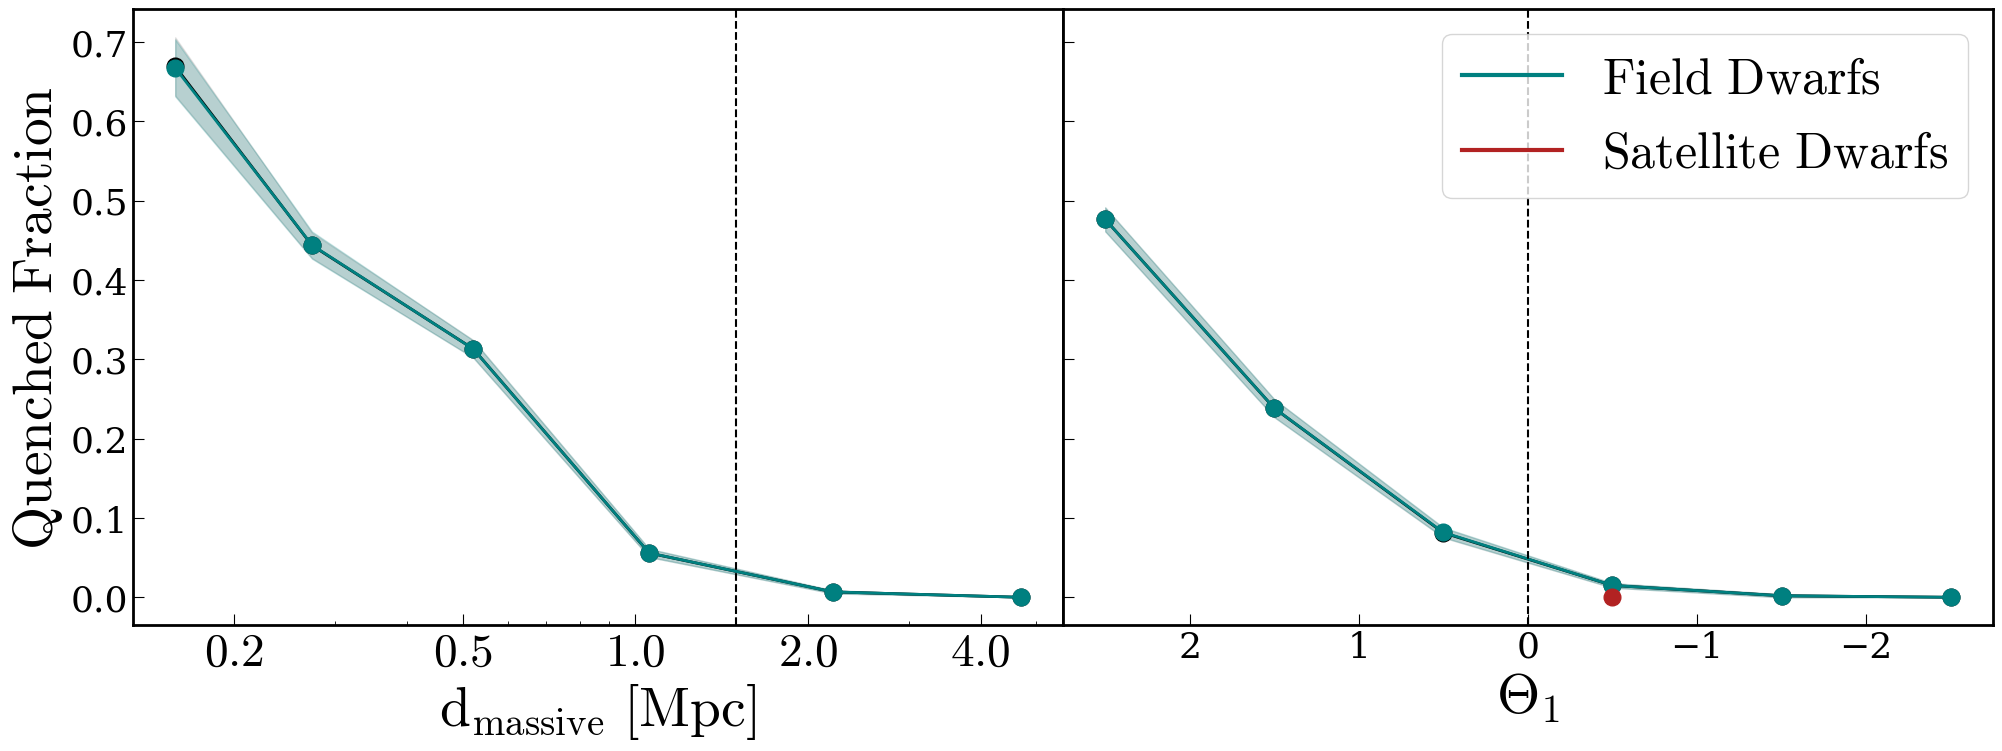

In [25]:
fig,ax=plt.subplots(1,2,figsize=(24,8),sharey=True)
bin_cols = ['teal','firebrick']

tracer_bins = [np.logspace(np.log10(0.1),np.log10(10),7),np.linspace(-3,3,7)]
tracer_bw = [0.5*(tb[1]-tb[0]) for tb in tracer_bins]

Nbtsp = 1000

'''boot_qncall, boot_qfeall = np.zeros((2,Nbtsp,20)),np.zeros((2,Nbtsp,20))
qnc_c = np.zeros(2)

slc = llg_a[host_isol[0]]        
qnc_c[0] = np.sum(1- np.heaviside(gls.sub.ssfr[slc]-(sfms_intercept -1 + sfms_slope*gls.sub.mst[slc]),1))/len(slc) 
            
slc = llg_a[host_isol[1]]
qnc_c[1] = np.sum(1- np.heaviside(gls.sub.ssfr[slc]-(sfms_intercept -1 + sfms_slope*gls.sub.mst[slc]),1))/len(slc) 
print(qnc_c[0],qnc_c[1])'''
boot_qnc = np.zeros((2,Nbtsp,6))
for m in range(Nbtsp):
            boot = npr.choice(range(np.sum(N_lll)),size=np.sum(N_lll),replace=True)

            dhost_b = [dhost_a[i] for i in boot]
            llt_b = np.array([llt_a[i] for i in boot])
            #llh_b = np.array([llh[i] for i in boot for m in range(llm[i])])
        
            mst_b = [mst_a[i] for i in boot]
            ssfr_b = [ssfr_a[i] for i in boot]
    
            qnc_b = 1-np.heaviside(ssfr_b-(sfms_intercept -1 + sfms_slope*np.array(mst_b)),1)
        
            bin_qnc, bin_edg, bin_n = sts.binned_statistic(dhost_b,qnc_b,statistic='mean', bins=tracer_bins[0])
            boot_qnc[0,m,:] = bin_qnc
            #boot_qfeall[0,m] = (bin_qnc-qnc_c[0])/(1-qnc_c[0])     
        
            bin_qnc, bin_edg, bin_n = sts.binned_statistic(llt_b,qnc_b,statistic='mean', bins=tracer_bins[1])
            boot_qnc[1,m,:] = bin_qnc
            #boot_qfeall[1,m] = (bin_qnc-qnc_c[1])/(1-qnc_c[1])

for j in range(2):
    boot_val=np.mean(boot_qnc[j,:,:],axis=0)
    boot_err=np.std(boot_qnc[j,:,:],axis=0,ddof=1)
    
    ax[j].plot(tracer_bins[j][:-1]+tracer_bw[j],boot_val,lw=2,marker='o',color='black',markersize=12)
    ax[j].fill_between(tracer_bins[j][:-1]+tracer_bw[j],boot_val-boot_err,boot_val+boot_err,color='gray',alpha=0.2)
'''
    boot_val=np.mean(boot_qfeall[j,:,:],axis=0)
    boot_err=np.std(boot_qfeall[j,:,:],axis=0,ddof=1)
    
    ax[1,j].plot(tracer_bins0[j][:-1]+tracer_bw0[j],boot_val,lw=2,marker='o',color='black',markersize=12)
    ax[1,j].fill_between(tracer_bins0[j][:-1]+tracer_bw0[j],boot_val-boot_err,boot_val+boot_err,color='gray',alpha=0.2)

'''

for j in range(2):
    boot_qnc = np.zeros((2,Nbtsp,6))
    for m in range(Nbtsp):
            boot = npr.choice(host_bins[j],size=len(host_bins[j]),replace=True)
    
            dhost_b = [dhost_a[i] for i in boot]
            llt_b = np.array([llt_a[i] for i in boot])
            #llh_b = np.array([llh[i] for i in boot for m in range(llm[i])])
        
            mst_b = [mst_a[i] for i in boot]
            ssfr_b = [ssfr_a[i] for i in boot]
        
            qnc_b = 1-np.heaviside(ssfr_b-(sfms_intercept -1 + sfms_slope*np.array(mst_b)),1)
    
            bin_qnc, bin_edg, bin_n = sts.binned_statistic(dhost_b,qnc_b,statistic='mean', bins=tracer_bins[0])
            boot_qnc[0,m,:] = bin_qnc

            bin_qnc, bin_edg, bin_n = sts.binned_statistic(llt_b,qnc_b,statistic='mean', bins=tracer_bins[1])
            boot_qnc[1,m,:] = bin_qnc
        
    for k in range(2):
        boot_val = np.mean(boot_qnc[k,:,:],axis=0)
        boot_err = np.std(boot_qnc[k,:,:],axis=0,ddof=1)
    
        ax[k].plot(tracer_bins[k][:-1]+tracer_bw[k],boot_val,lw=2,marker='o',color=bin_cols[j],markersize=12)
        ax[k].fill_between(tracer_bins[k][:-1]+tracer_bw[k],boot_val-boot_err,boot_val+boot_err,color=bin_cols[j],alpha=0.2)
'''        
        boot_val = np.mean(boot_qfe[k,:,:],axis=0)
        boot_err = np.std(boot_qfe[k,:,:],axis=0,ddof=1)
    
        ax[1,k].plot(tracer_bins1[k][:-1]+tracer_bw1[k],boot_val,lw=2,marker='o',color=bin_cols[j],markersize=12)
        ax[1,k].fill_between(tracer_bins1[k][:-1]+tracer_bw1[k],boot_val-boot_err,boot_val+boot_err,color=bin_cols[j],alpha=0.2)

for k in range(2):
    ax[k].axhline(0.2,color='black',ls='-.')
'''
ax[0].set_xscale('log')
ax[0].axvline(1.5,color='black',ls='--')
ax[1].axvline(0,color='black',ls='--')
ax[1].invert_xaxis()
xticks = [0.2,0.5,1.0, 2,4]
xlabels = [f'${x:1.1f}$' for x in xticks]
ax[0].set_xticks(xticks, labels=xlabels,fontsize=34)

ax[0].set_ylabel(r'$Quenched\ Fraction$',fontsize=40)
#ax[0].set_ylabel(r'$Quenching\ Efficiency$',fontsize=30)
ax[0].set_xlabel(r'$d_{massive}\ [Mpc]$',fontsize=40)
ax[1].set_xlabel(r'$\Theta_1$',fontsize=40)

custom_lines = [Line2D([0], [0],lw=3, color=bin_cols[0]), Line2D([0], [0],lw=3, color=bin_cols[1])]
leg=Legend(ax[1],custom_lines,[r'$Field\ Dwarfs$',r'$Satellite\ Dwarfs$'],loc='upper right',fontsize=36,framealpha=0.8,frameon=True)
ax[1].add_artist(leg)

plt.subplots_adjust(wspace=0.0,hspace=0.0)
#plt.savefig('Bquenchtracer_geha12.pdf',bbox_inches='tight')


In [44]:
dw_samp = [np.where((m200_a<11.5)&(mst_a<9.5))[0],np.where((m200_a>=11.5)&(mst_a<9.5)&(x200_a>=1))[0]]
print(len(dw_samp[0]),len(dw_samp[1]))


5983 4856


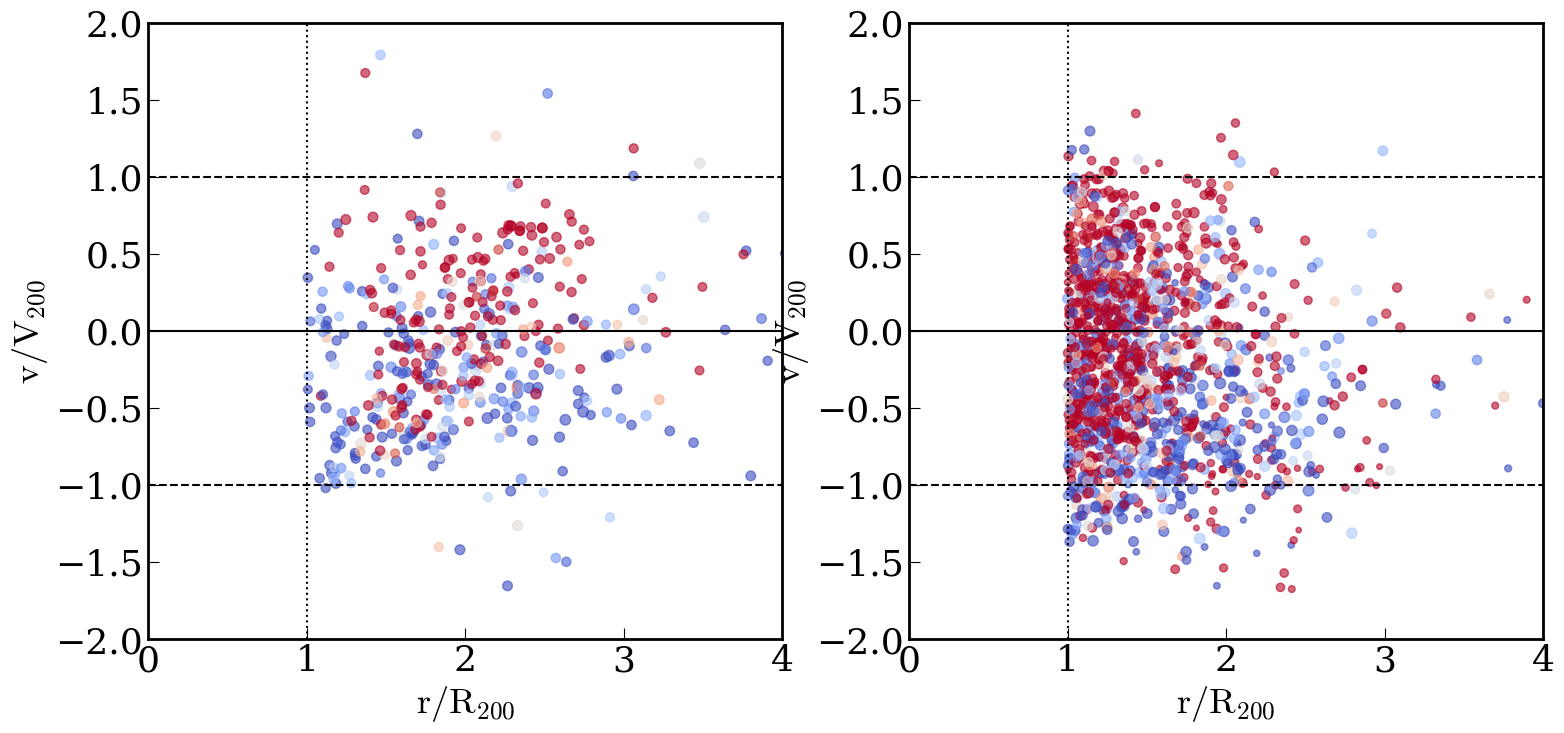

In [40]:
fig,ax=plt.subplots(1,2,figsize=(18,8))

mdyn_a = 10.155 + np.log10( np.array([gls.sub.SubhaloMass[l] for k in range(3) for l in llg[k]]))
qnc_a = ssfr_a-(sfms_intercept + sfms_slope*np.array(mst_a))

for k in range(2):
    ax[k].scatter(x200_a[dw_samp[k]],v200_a[dw_samp[k]],c=qnc_a[dw_samp[k]],s=(0.25*mdyn_a[dw_samp[k]])**4,cmap=mcm.coolwarm_r,vmin=-1,vmax=0,alpha=0.6)

    ax[k].set_xlim((0,4))
    ax[k].set_ylim((-2,2))
    ax[k].axhline(-1,color='black',ls='--')
    ax[k].axhline(0,color='black')
    ax[k].axhline(1,color='black',ls='--')
    ax[k].axvline(1,color='black',ls=':')

    ax[k].set_xlabel(r'$r/R_{200}$',fontsize=26)
    ax[k].set_ylabel(r'$v/V_{200}$',fontsize=26)

#fig.colorbar(mcm.ScalarMappable(norm=mcol.Normalize(vmin=-1, vmax=0),cmap=mcm.coolwarm_r), ax=ax[1], orientation='vertical',label=r'$\Delta\ log(sSFR/yr^{-1})$')




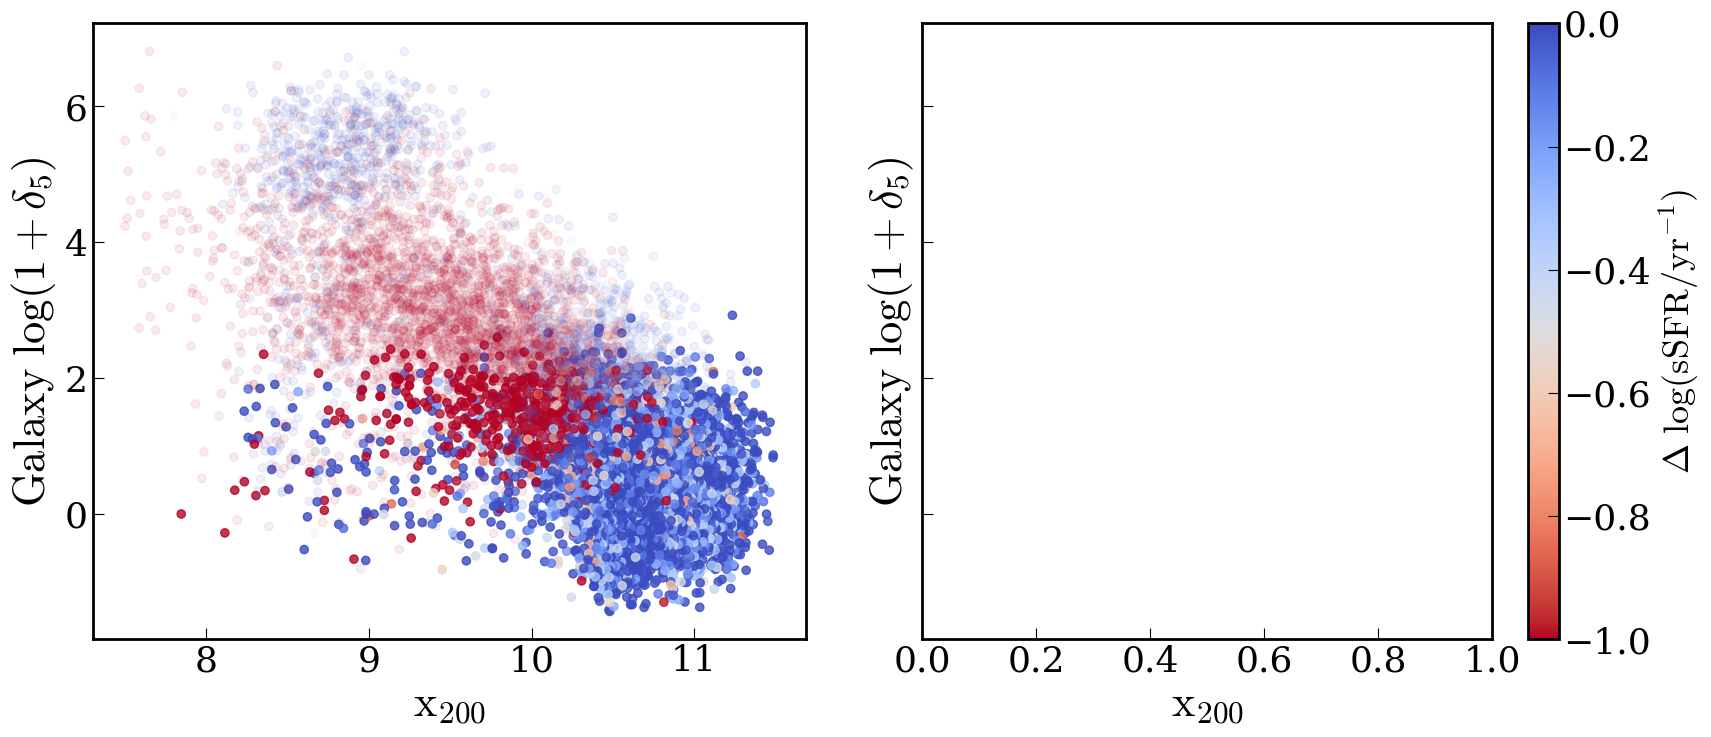

In [45]:
fig,ax=plt.subplots(1,4,figsize=(20,8),width_ratios=[0.46,0.075,0.46,0.005],sharey=True)

mdyn_a = 10.155 + np.log10( np.array([gls.sub.SubhaloMass[l] for k in range(3) for l in llg[k]]))
qnc_a = ssfr_a-(sfms_intercept + sfms_slope*np.array(mst_a))
#mag_samp = np.where((mst_a<9.5)&(qnc_a>1))[0]
#dhost_out = np.where((m200_a>=11.5)&(mst_a<9.5))[0]
#print(len(dhost_out))

ax[0].set_ylabel(r'$Galaxy\ log(1+\delta_5)$',fontsize=32)
ax[0].set_xlabel(r'$x_{200}$',fontsize=32)

ax[0].scatter(mdyn_a[dw_samp[0]],llr_a[dw_samp[0]],c=qnc_a[dw_samp[0]],cmap=mcm.coolwarm_r,vmin=-1, vmax=0,alpha=0.8)
ax[0].scatter(mdyn_a[dw_samp[1]],llr_a[dw_samp[1]],c=qnc_a[dw_samp[1]],cmap=mcm.coolwarm_r,vmin=-1, vmax=0,alpha=0.08)
#ax[2].scatter(m200_a[dw_samp],llr_a[dw_samp],c='none',edgecolors='black',marker='o',linewidth=0.5,alpha=0.2)

#ax[2].axvline(11.5,color='black')
#ax[2].axhline(2,color='black',ls='--')

ax[2].set_ylabel(r'$Galaxy\ log(1+\delta_5)$',fontsize=32)
ax[2].set_xlabel(r'$x_{200}$',fontsize=32)

ax[1].set_axis_off()
ax[3].set_axis_off()

fig.colorbar(mcm.ScalarMappable(norm=mcol.Normalize(vmin=-1, vmax=0),cmap=mcm.coolwarm_r), ax=ax[2], orientation='vertical',label=r'$\Delta\ log(sSFR/yr^{-1})$')

ax[0].set_rasterized(True)
ax[2].set_rasterized(True)
plt.subplots_adjust(wspace=0.0)
#plt.savefig('dens_mapv2.pdf',bbox_inches='tight')

#plt.savefig('tidal_mst.pdf',bbox_inches='tight')




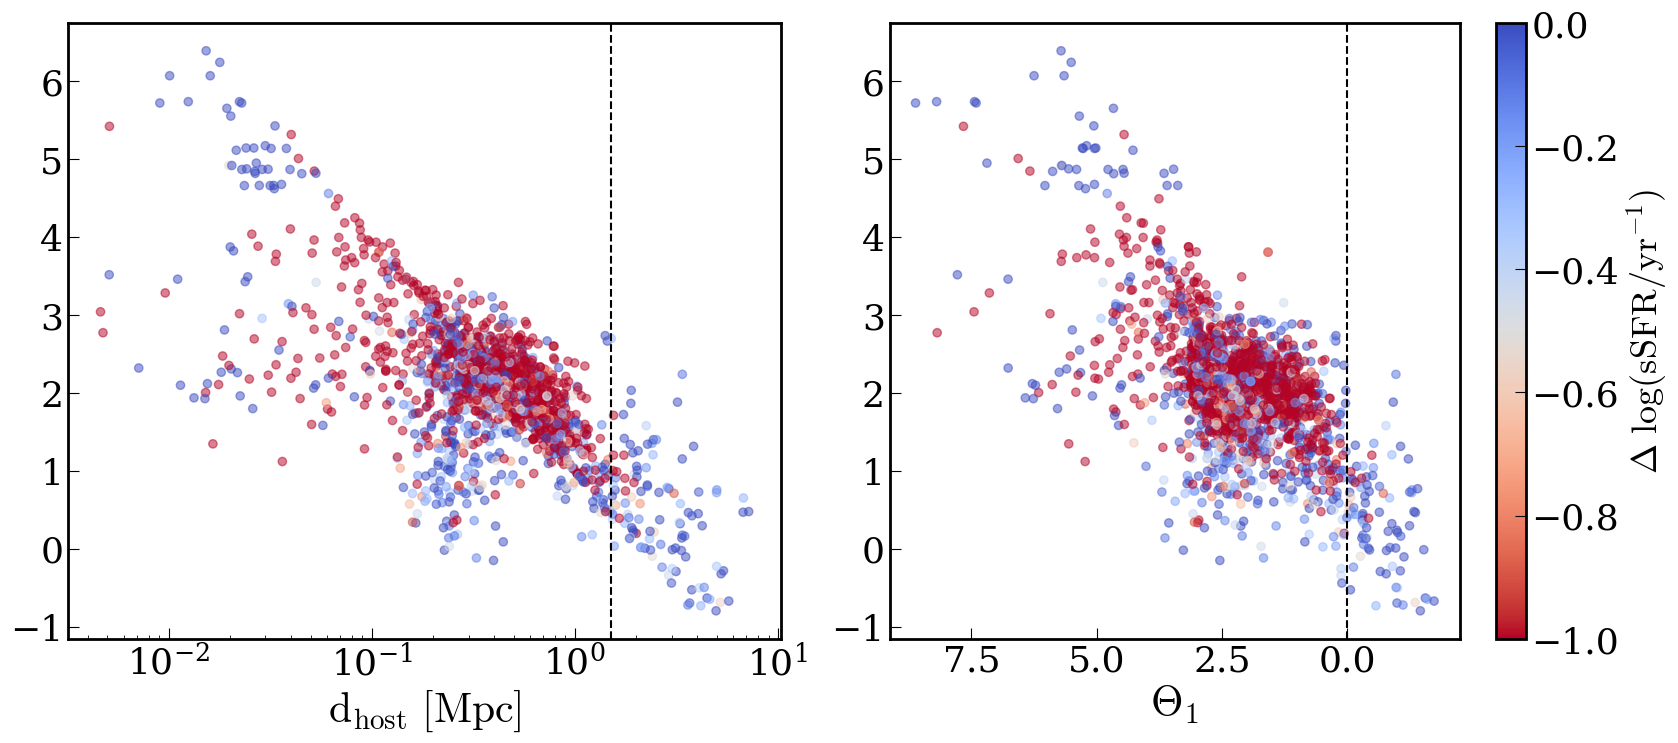

In [21]:
fig,ax=plt.subplots(1,4,figsize=(20,8),width_ratios=[0.46,0.07,0.46,0.01])

#dens_srt = np.sort(llr_a)
#print(dens_srt)
#den_scr = sts.percentileofscore(dens_srt,llr_a)

ax[0].scatter(dhost_a[dw_samp],llr_a[dw_samp],c=qnc_a[dw_samp],cmap=mcm.coolwarm_r,vmin=-1, vmax=0,alpha=0.5)
ax[2].scatter(llt_a[dw_samp],llr_a[dw_samp],c=qnc_a[dw_samp],cmap=mcm.coolwarm_r,vmin=-1, vmax=0,alpha=0.5)

#ax[0].set_xlim((7,9.5))
#ax[0].set_xlabel(r'$log(1+\delta_5)$',fontsize=30)
#ax[2].set_xlabel(r'$log(1+\delta_5)$',fontsize=30)
ax[2].set_xlabel(r'$\Theta_1$',fontsize=30)
ax[0].set_xlabel(r'$d_{host}\ [Mpc]$',fontsize=30)

ax[0].set_xscale('log')
ax[2].invert_xaxis()

ax[0].axvline(1.5,color='black',ls='--')
ax[2].axvline(0,color='black',ls='--')

ax[1].set_axis_off()
ax[3].set_axis_off()

fig.colorbar(mcm.ScalarMappable(norm=mcol.Normalize(vmin=-1, vmax=0),cmap=mcm.coolwarm_r), ax=ax[2], orientation='vertical',label=r'$\Delta\ log(sSFR/yr^{-1})$')
ax[0].set_rasterized(True)
ax[2].set_rasterized(True)
plt.subplots_adjust(wspace=0.0)
#plt.savefig('tidal_mst.pdf',bbox_inches='tight')